# Commodity Markov-Switching Extension - Two Pipelines
## Xavier Jaeger · Bachelor Thesis · Erasmus University Rotterdam

Two fully independent end-to-end pipelines:

| Pipeline | r_total | k Pass 2 | Motivation |
|---|---|---|---|
| **P1** | 12 (MST-comparable) | 6 | Directly comparable to MST hard-threshold |
| **P2** | AH-selected (~2) | AH-selected | Data-driven, BM-consistent |

Each pipeline runs its own EM, produces its own xi_bear, and reports its own
pricing results. The cross-pipeline DoC at the end quantifies how different
the two regime identifications are.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
np.random.seed(19780308)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

# File paths
PATH_RETURNS  = 'Input/test_asset_universe.csv'                 # weekly, N=130
PATH_ADBEAR   = 'Input/ADBear_Monthly_Formation.csv'
PATH_MST_DATES = 'Input/mExcess_Returns_Farago_Tedongap_201508_LM.csv'
PATH_FACTORS  = 'Input/pass3_factors.csv'                       # weekly, 4 factors

# Fixed parameters
R_LAG        = 1
THETA_HAT    = 0.1250      # commodity MST full-sample threshold (Table 4)
N_FACTORS    = 6           # MST factors per regime
R_TOTAL      = 12          # MS total factors r1+r2
EM_MAX_ITER  = 500
EM_TOL       = 1e-7
EM_OMEGA1    = 0.20        # bull persistence offset
EM_OMEGA2    = 0.10        # bear persistence offset

print(f'  THETA_HAT={THETA_HAT} (commodity MST full-sample)')
print(f'  R_TOTAL={R_TOTAL}, N_FACTORS={N_FACTORS}')


  THETA_HAT=0.125 (commodity MST full-sample)
  R_TOTAL=12, N_FACTORS=6


In [2]:
# SHARED HELPERS - identical to ms_equity_final.ipynb

def mst_demean(X, d):
    X_na = (X * d[:,None]).astype(float)
    X_na[d==0] = np.nan
    mu   = np.nanmean(X_na, axis=0)
    Xdm  = np.nan_to_num(X_na - mu, nan=0.0)
    return Xdm, mu

def mst_pca(Xdm, k, N):
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm)
    idx = np.argsort(ev)[::-1]
    return np.sqrt(N) * evec[:, idx[:k]]

def mst_gamma(X_ret_full, B, k, T_j):
    Bk = B[:,:k]
    return (np.linalg.inv(Bk.T@Bk+1e-12*np.eye(k)) @ Bk.T @ X_ret_full.T).sum(1)/T_j

def compute_rmspe(pe, N): return np.sqrt(pe@pe/N)

def compute_adjr2(rmspe_val, R_bar, N, k):
    ss  = R_bar @ R_bar
    r2  = 1 - N*rmspe_val**2/ss if ss!=0 else np.nan
    return 1 - (1-r2)*N/(N-k) if ss!=0 else np.nan

def newey_west_se(x, lags=None):
    T_ = len(x)
    if lags is None: lags = int(np.floor(4*(T_/100)**(2/9)))
    xc = x - x.mean(); s2 = np.dot(xc,xc)/T_
    for l in range(1,lags+1):
        s2 += 2*(1-l/(lags+1))*np.dot(xc[l:],xc[:-l])/T_
    return np.sqrt(max(s2/T_,1e-30))

def fm_tstats(X_ret, w, B, k):
    BtB_inv  = np.linalg.inv(B[:,:k].T@B[:,:k]+1e-10*np.eye(k))
    gamma_ts = (BtB_inv @ B[:,:k].T @ X_ret.T).T
    w_norm   = w / (w.sum()+1e-10)
    gbar     = (w_norm[:,None]*gamma_ts).sum(0)
    se       = np.array([newey_west_se(w*gamma_ts[:,j]) for j in range(k)])
    se       = np.where(se>0, se, 1e-10)
    return gbar, se, gbar/se



In [3]:
# Compound weekly returns to monthly
def compound(x): return (1+x).prod()-1

# Load test asset universe
ret_weekly = pd.read_csv(PATH_RETURNS, index_col=0, parse_dates=True)
ret_weekly.index = pd.to_datetime(ret_weekly.index)
ret_monthly_raw = ret_weekly.resample('ME').apply(compound)

# Load ADBear and align to commodity monthly dates
adb_raw  = pd.read_csv(PATH_ADBEAR)
mst_raw  = pd.read_csv(PATH_MST_DATES)
mst_dates = (pd.to_datetime(mst_raw['Date'].astype(str), format='%Y%m')
             + pd.offsets.MonthEnd(0))
adb_series = pd.Series(
    adb_raw['ADBearRF_Average_within_the_Month'].values, index=mst_dates)

# Restrict to ADBear overlap: Feb 1997 - Aug 2015
common_idx  = ret_monthly_raw.index.intersection(adb_series.index)
ret_monthly = ret_monthly_raw.loc[common_idx].ffill().bfill()
adb_aligned = adb_series.loc[common_idx]

# Apply one-month lag
X       = ret_monthly.iloc[R_LAG:, :].values.astype(float)   # T x N
adb     = adb_aligned.values[:-R_LAG]                        # lagged ADBear
dates   = ret_monthly.index[R_LAG:]
T, N    = X.shape

# Whole-sample demeaning
X_mean  = X.mean(0)
X_dm    = X - X_mean

# Load Pass 3 commodity factors
fac_weekly  = pd.read_csv(PATH_FACTORS, index_col=0, parse_dates=True)
fac_weekly.index = pd.to_datetime(fac_weekly.index)
fac_monthly = fac_weekly.resample('ME').apply(compound)
G_factors   = fac_monthly.reindex(dates).values   # T x 4
factor_names = fac_weekly.columns.tolist()

print(f'Data: T={T}, N={N}')
print(f'Sample: {dates[0].strftime("%b %Y")} - {dates[-1].strftime("%b %Y")}')
print(f'ADBear: mean={adb.mean():.4f}, theta={THETA_HAT}')
print(f'Pass 3 factors: {factor_names}, missing={np.isnan(G_factors).sum()}')

# A10: Finite-sample caveat
T_over_N = T / N
T_eff_bear_approx = T * 0.33   # approximate bear fraction
print(f'\nFinite-sample diagnostics (BM Assumption A10):')
print(f'  T={T}, N={N},  T/N = {T_over_N:.2f}')
print(f'  BM smallest app: N=49, T=630, T/N=12.9')
print(f'  Approx bear T_eff ~ {T_eff_bear_approx:.0f}')
if T_over_N < 2.0:
    print(f'  [CAUTION] T/N={T_over_N:.2f} < 2.0 - asymptotic results may be imprecise.')
    print(f'  Bear loading estimates particularly noisy: T_eff/N ~ {T_eff_bear_approx/N:.2f}')
else:
    print(f'  T/N ratio acceptable for BM asymptotics.')


Data: T=223, N=130
Sample: Feb 1997 - Aug 2015
ADBear: mean=-0.2867, theta=0.125
Pass 3 factors: ['BM', 'MOM', 'HP', 'BASIS'], missing=0

Finite-sample diagnostics (BM Assumption A10):
  T=223, N=130,  T/N = 1.72
  BM smallest app: N=49, T=630, T/N=12.9
  Approx bear T_eff ~ 74
  [CAUTION] T/N=1.72 < 2.0 - asymptotic results may be imprecise.
  Bear loading estimates particularly noisy: T_eff/N ~ 0.57


In [4]:
# Regime dummies
d_D = (adb >= THETA_HAT).astype(float)
d_S = 1.0 - d_D
T_D = int(d_D.sum()); T_S = int(d_S.sum())
print(f'MST: T_D={T_D} ({T_D/T:.1%} bear), T_S={T_S} ({T_S/T:.1%} bull)')

# Pass 1: PCA
Xdm_D, X_D_mean = mst_demean(X, d_D)
Xdm_S, X_S_mean = mst_demean(X, d_S)

B_D   = mst_pca(Xdm_D, N_FACTORS, N)
B_S   = mst_pca(Xdm_S, N_FACTORS, N)
B_mst = mst_pca(X_dm,  N_FACTORS, N)

# Pass 2: risk premia
gamma_D   = mst_gamma(X*d_D[:,None], B_D, N_FACTORS, T_D)
gamma_S   = mst_gamma(X*d_S[:,None], B_S, N_FACTORS, T_S)

pe_D = X_D_mean - B_D @ gamma_D
pe_S = X_S_mean - B_S @ gamma_S

gb_D, se_D, t_D = fm_tstats(X[d_D==1], np.ones(T_D), B_D, N_FACTORS)
gb_S, se_S, t_S = fm_tstats(X[d_S==1], np.ones(T_S), B_S, N_FACTORS)

print(f'\nCommodity MST Pass 2 (monthly %):')
print(f'  Bear: gamma_1={gamma_D[0]*12*100:.2f}%pa  RMSPE={compute_rmspe(pe_D,N)*12*100:.4f}%pa')
print(f'  Bull: gamma_1={gamma_S[0]*12*100:.2f}%pa  RMSPE={compute_rmspe(pe_S,N)*12*100:.4f}%pa')
print(f'\nADBear stats by regime:')
print(f'  Bear: ADBear mean={adb[d_D==1].mean():.4f}')
print(f'  Bull: ADBear mean={adb[d_S==1].mean():.4f}')
print(f'  Bear return: {X[d_D==1].mean()*12*100:.2f}%pa')
print(f'  Bull return: {X[d_S==1].mean()*12*100:.2f}%pa')


MST: T_D=73 (32.7% bear), T_S=150 (67.3% bull)



Commodity MST Pass 2 (monthly %):
  Bear: gamma_1=-11.56%pa  RMSPE=6.5171%pa
  Bull: gamma_1=17.14%pa  RMSPE=5.1059%pa

ADBear stats by regime:
  Bear: ADBear mean=1.0100
  Bull: ADBear mean=-0.9178
  Bear return: -10.78%pa
  Bull return: 16.34%pa


In [5]:
# Unconditional fit (the one missing piece)
X_mean_full = X.mean(axis=0)
Xdm_full    = X - X_mean_full

B_unc     = mst_pca(Xdm_full, N_FACTORS, N)
gamma_unc = mst_gamma(X, B_unc, N_FACTORS, T)
F_wm_unc  = X @ B_unc / N

pe_unc_D = X_D_mean - B_unc @ gamma_unc[:N_FACTORS]   # unconditional model's
pe_unc_S = X_S_mean - B_unc @ gamma_unc[:N_FACTORS]   # error on each regime

rmspe_unc_D = compute_rmspe(pe_unc_D, N)
rmspe_unc_S = compute_rmspe(pe_unc_S, N)
rmspe_mst_D = compute_rmspe(pe_D, N)   # already in scope, conditional MST
rmspe_mst_S = compute_rmspe(pe_S, N)

---
## Shared: PCA Linear Representation & AH Factor Selection

In [ ]:
def pca_linear_rep(Xdm, r):
    T_, N_ = Xdm.shape
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm / T_)
    idx  = np.argsort(ev)[::-1]
    A    = np.sqrt(N_) * evec[:, idx[:r]]
    G    = Xdm @ A / N_
    return A, G, ev[idx]

def ahn_horenstein_skip1(eigvals, r_max=10):
    """AH (2013) Growth Ratio criterion, skip-first modification.
    Matches BM replication package (main_FamaFrench_FINAL.m).
    r_hat is the TOTAL number of factors r1+r2.
    """
    r_max  = min(r_max, len(eigvals)-3)
    # GR: log(1+lambda_j) / log(1+lambda_{j+1}) - BM uses GR not ER
    ratios = np.log(1 + eigvals[1:r_max+1]) / np.log(1 + eigvals[2:r_max+2])
    r_hat  = int(np.argmax(ratios) + 2)   # +2: skip eig1, ratio array starts at eig2
    return r_hat, ratios

# Full-sample AH selection (used to set Pipeline 2 r_total)
S            = X_dm.T @ X_dm / T
eigvals_full = np.linalg.eigvalsh(S)[::-1]
r_ah_full, ratios_full = ahn_horenstein_skip1(eigvals_full, r_max=12)
pve_full = eigvals_full[:r_ah_full].sum() / eigvals_full.sum()

print(f'Full-sample AH (skip k=1): r_hat = {r_ah_full}')
print(f'Ratios k=2..12: {np.round(ratios_full[:11], 3)}')
print(f'PVE at r_ah={r_ah_full}: {pve_full:.1%}')

R_TOTAL_P1 = 12
# r_ah_full is r_TOTAL per BM: AH selects total factors, BM assumes r1=r2=r_total/2
# Floor: max(r_ah_full, 2) ensures at least 1 factor per regime (BM Assumption 2b)
R_TOTAL_P2 = max(r_ah_full, 2)   # r_total; floor at 2 so r1=r2>=1
K_P1       = N_FACTORS            # = 6
K_P2       = R_TOTAL_P2 // 2     # = 1 (AH-selected per regime)
print(f'Pipeline 1 will use r_total={R_TOTAL_P1}, k={K_P1} (MST-comparable)')
print(f'Pipeline 2 will use r_total={R_TOTAL_P2}, k={K_P2} (BM-consistent)')

Full-sample AH (skip k=1): r_hat = 2
Ratios k=2..12: [2.358 1.336 1.176 1.148 1.068 1.169 1.187 1.089 1.084 1.135 1.145]
PVE at r_ah=2: 63.8%
Pipeline 1 will use r_total=12, k=6 (MST-comparable)
Pipeline 2 will use r_total=2, k=1 (BM-consistent)


---
## Shared: EM Functions (BLHK Filter/Smoother/M-Step)

In [7]:
def blhk_filter(Xdm, G, B1, B2, sig1, sig2, P):
    T_, N_ = Xdm.shape
    p11, p22 = P[0,0], P[1,1]
    denom = 2-p11-p22+1e-12
    xi_prev = np.array([(1-p22)/denom, (1-p11)/denom])
    xi_filt = np.empty((T_,2)); xi_pred = np.empty((T_,2))
    lc = N_ * np.log(2*np.pi)
    for t in range(T_):
        xip = P.T @ xi_prev; xi_pred[t] = xip
        r1t = Xdm[t]-G[t]@B1.T; r2t = Xdm[t]-G[t]@B2.T
        ll1 = -0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1))+lc)
        ll2 = -0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2))+lc)
        lm  = max(ll1,ll2)
        eta = np.array([np.exp(ll1-lm), np.exp(ll2-lm)])
        num = eta*xip; s = num.sum()
        xi_filt[t] = num/s if s>1e-300 else xip
        xi_prev = xi_filt[t]
    return xi_filt, xi_pred

def blhk_smoother(xi_filt, xi_pred, P):
    T_ = xi_filt.shape[0]
    xi_smooth = np.empty((T_,2)); xi_cross = np.zeros((T_,2,2))
    xi_smooth[-1] = xi_filt[-1]
    for t in range(T_-2,-1,-1):
        sp  = np.where(xi_pred[t+1]>1e-300, xi_pred[t+1], 1e-300)
        raw = xi_filt[t]*(P @ (xi_smooth[t+1]/sp))
        s   = raw.sum(); xi_smooth[t] = raw/s if s>1e-300 else xi_filt[t]
        for j in range(2):
            for k in range(2):
                xi_cross[t+1,j,k] = P[j,k]*xi_filt[t,k]*xi_smooth[t+1,j]/max(xi_pred[t+1,j],1e-300)
        sc = xi_cross[t+1].sum()
        if sc>1e-300: xi_cross[t+1] /= sc
    return xi_smooth, xi_cross

def m_step(Xdm, G, xi_smooth, xi_cross, homoskedastic=False):
    T_, N_ = Xdm.shape; r = G.shape[1]
    B_new=[]; sig_new=[]
    for j in range(2):
        w   = xi_smooth[:,j]
        wXG = (Xdm*w[:,None]).T @ G
        wGG = (G*w[:,None]).T @ G + 1e-10*np.eye(r)
        Bj  = wXG @ np.linalg.inv(wGG); B_new.append(Bj)
        res = Xdm - G @ Bj.T
        sig_new.append(np.maximum((w[:,None]*res**2).sum(0)/max(w.sum(),1e-10), 1e-8))
    sum_cross = xi_cross[1:].sum(0); sum_xi = xi_smooth[:-1].sum(0)
    Pnew = np.zeros((2,2))
    for j in range(2):
        for k in range(2):
            Pnew[j,k] = sum_cross[j,k]/max(sum_xi[k],1e-10)
    # A3: homoskedastic option - pool variances across regimes (BM macro application)
    if homoskedastic:
        _w0 = xi_smooth[:,0].sum()
        _w1 = xi_smooth[:,1].sum()
        sig_pooled = (_w0 * sig_new[0] + _w1 * sig_new[1]) / (_w0 + _w1)
        sig_new = [sig_pooled, sig_pooled]
    Pnew = np.clip(Pnew/Pnew.sum(0,keepdims=True), 1e-5, 1-1e-5)
    Pnew /= Pnew.sum(0,keepdims=True)
    return B_new[0], B_new[1], sig_new[0], sig_new[1], Pnew

def log_lik(Xdm, G, B1, B2, sig1, sig2, P):
    T_,N_=Xdm.shape; p11,p22=P[0,0],P[1,1]; d=2-p11-p22+1e-12
    xip=np.array([(1-p22)/d,(1-p11)/d]); ll=0.; lc=N_*np.log(2*np.pi)
    for t in range(T_):
        xip=P.T@xip; r1t=Xdm[t]-G[t]@B1.T; r2t=Xdm[t]-G[t]@B2.T
        ll1=-0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1))+lc)
        ll2=-0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2))+lc)
        lm=max(ll1,ll2); e1,e2=np.exp(ll1-lm),np.exp(ll2-lm)
        mix=xip[0]*e1+xip[1]*e2; ll+=np.log(max(mix,1e-300))+lm
        num=np.array([e1*xip[0],e2*xip[1]]); s=num.sum()
        xip=num/s if s>1e-300 else xip
    return ll/(N_*T_)



In [8]:
def run_em_pipeline(X_dm, r_total, k_stars, label='', rng=None, verbose=True):
    """
    Full EM pipeline for one factor-count specification.
    Returns: B1, B2, sig1, sig2, P, xi_bear, xi_bull, best_ll, A_hat, G_hat
    k_stars: number of factors per regime to report (used for Pass 2/3)
    """
    if rng is None: 
        rng = np.random.default_rng(19780308)
    A_hat, G_hat, eigvals = pca_linear_rep(X_dm, r_total)
    e_init = X_dm - G_hat @ A_hat.T
    pve    = eigvals[:r_total].sum() / eigvals.sum()
    if verbose: print(f'\n[{label}] PCA: r_total={r_total}, PVE={pve:.1%}')
    if verbose: print(f'  A_hat={A_hat.shape}, G_hat={G_hat.shape}')

    omega_grid = [
        (0.20,0.10),(0.40,0.05),(0.10,0.40),(0.30,0.30),(0.45,0.20),
        (0.15,0.35),(0.35,0.15),(0.25,0.25),(0.40,0.30),(0.10,0.10),
    ]
    
    while len(omega_grid) < 20:
        omega_grid.append((rng.uniform(0.05,0.48), rng .uniform(0.05,0.48)))

    best_ll_ = -np.inf; best_params_ = None
    if verbose: print(f'  Multi-start EM ({len(omega_grid)} starts)...')
    if verbose: print(f'  {"Start":>5}  {"final_ll":>14}  {"p11":>7}  {"p22":>7}  {"xi2_mean":>9}')
    if verbose: print('  '+'-'*50)

    for s_, (o1, o2) in enumerate(omega_grid):
        B1_ = A_hat.copy(); B2_ = A_hat.copy()
        sig1_ = np.maximum(np.var(e_init,0),1e-8); sig2_=sig1_.copy()
        P_ = np.array([[0.5+o1,1-0.5-o1],[1-0.5-o2,0.5+o2]])
        ll_p = -np.inf
        for it_ in range(EM_MAX_ITER):
            xf_,xp_ = blhk_filter(X_dm,G_hat,B1_,B2_,sig1_,sig2_,P_)
            xs_,xc_ = blhk_smoother(xf_,xp_,P_)
            B1_,B2_,sig1_,sig2_,P_ = m_step(X_dm,G_hat,xs_,xc_)
            ll_ = log_lik(X_dm,G_hat,B1_,B2_,sig1_,sig2_,P_)
            delta_ = abs(ll_-ll_p)/max(0.5*(abs(ll_)+abs(ll_p)),1e-10) if it_>0 else 1
            if delta_<EM_TOL and it_>5: break
            ll_p = ll_
        # frequency label
        xs_f_=xs_.copy(); xf_f_=xf_.copy()
        if xs_f_[:,1].mean()>xs_f_[:,0].mean():
            xs_f_=xs_f_[:,[1,0]]; xf_f_=xf_f_[:,[1,0]]
            B1_,B2_=B2_.copy(),B1_.copy()
            sig1_,sig2_=sig2_.copy(),sig1_.copy()
            P_=P_[[1,0],:][:,[1,0]]
        if verbose: print(f'  {s_+1:>5}  {ll_:>14.8f}  {P_[0,0]:>7.4f}  {P_[1,1]:>7.4f}  {xs_f_[:,1].mean():>9.4f}')
        if ll_ > best_ll_:
            best_ll_=ll_
            best_params_=(B1_.copy(),B2_.copy(),sig1_.copy(),sig2_.copy(),
                          P_.copy(),xs_f_.copy(),xf_f_.copy())

    B1,B2,sig1,sig2,P,xs_f,xf_f = best_params_
    xi_bear_ = xs_f[:,1]; xi_bull_ = xs_f[:,0]
    p11_,p22_ = P[0,0],P[1,1]
    pi1_=(1-p22_)/(2-p11_-p22_+1e-12); pi2_=1-pi1_
    b_corr_ = np.corrcoef(B1.flatten(),B2.flatten())[0,1]

    if verbose: print(f'\n  Best ll={best_ll_:.6f}')
    if verbose: print(f'  P: p11={p11_:.4f}, p22={p22_:.4f}')
    if verbose: print(f'  pi_bull={pi1_:.4f}, pi_bear={pi2_:.4f}')
    if verbose: print(f'  E[bull]={1/(1-p11_):.1f}m, E[bear]={1/(1-p22_):.1f}m')
    if verbose: print(f'  xi_bear mean={xi_bear_.mean():.4f}')
    if verbose: print(f'  B1/B2 corr={b_corr_:.4f}')
    n_int = ((xi_bear_>0.05)&(xi_bear_<0.95)).sum()
    if verbose: print(f'  Interior P(bear): {n_int}/{T} = {n_int/T:.1%}')

    return (B1,B2,sig1,sig2,P,xi_bear_,xi_bull_,best_ll_,A_hat,G_hat,
            p11_,p22_)


def pipeline_pass2(X, B1, B2, xi_bear, xi_bull, k, N):
    """Pass 2 + NW t-stats for one pipeline."""
    def normalise(B, k_):
        cn = np.sqrt((B[:,:k_]**2).sum(0)/N)
        cn = np.where(cn>1e-10,cn,1.0)
        return B[:,:k_]/cn[None,:]
    B2n = normalise(B2,k); B1n = normalise(B1,k)
    def pass2(X_,Bj,xi_,k_):
        T_eff=xi_.sum(); Rbar=(xi_[:,None]*X_).sum(0)/T_eff
        Bk=Bj[:,:k_]
        gam=np.linalg.inv(Bk.T@Bk+1e-10*np.eye(k_))@Bk.T@Rbar
        alpha=Rbar-Bk@gam
        return gam,alpha,np.sqrt((alpha**2).mean()),Rbar,T_eff
    gD,aD,rD,RD,TeffD = pass2(X,B2n,xi_bear,k)
    gS,aS,rS,RS,TeffS = pass2(X,B1n,xi_bull,k)
    gbD,seD,tD = fm_tstats(X,xi_bear,B2n,k)
    gbS,seS,tS = fm_tstats(X,xi_bull,B1n,k)
    return dict(
        B2n=B2n,B1n=B1n,gD=gD,aD=aD,rD=rD,RD=RD,TeffD=TeffD,
        gS=gS,aS=aS,rS=rS,RS=RS,TeffS=TeffS,
        gbD=gbD,tD=tD,gbS=gbS,tS=tS,
        predD=B2n@gD, predS=B1n@gS
    )


def pipeline_pass3(G_factors, Xdm_D, Xdm_S, B_D, B_S, d_D, d_S, gamma_D, gamma_S,
                   p2, xi_bear, xi_bull, N, factor_names):
    """Pass 3 for both MST and MS, returns rotated premia dict."""
    def pass3_ms(G_obs,B_j,xi_j,gam_lat):
        k_=len(gam_lat); T_eff=xi_j.sum()
        G_bar=(xi_j[:,None]*G_obs).sum(0)/T_eff; G_dm=G_obs-G_bar
        Binv=np.linalg.inv(B_j[:,:k_].T@B_j[:,:k_]/N+1e-10*np.eye(k_))
        u=(X_dm@B_j[:,:k_]/N)@Binv.T
        num=(xi_j[:,None]*G_dm).T@u; den=(xi_j[:,None]*u).T@u+1e-10*np.eye(k_)
        Lam=num@np.linalg.inv(den)
        return Lam,(Lam@gam_lat).flatten()
    def pass3_mst(G_obs,Xdm_j,B_j,d_j,gam_j):
        G_bar=G_obs[d_j==1].mean(0); G_dm=G_obs-G_bar
        F_j=(Xdm_j@B_j/N)[d_j==1]; u=F_j[:,:len(gam_j)]
        num=(G_dm[d_j==1]).T@u; den=u.T@u+1e-10*np.eye(len(gam_j))
        Lam=num@np.linalg.inv(den)
        return Lam,(Lam@gam_j).flatten()
    _,gD_mst=pass3_mst(G_factors,Xdm_D,B_D,d_D,gamma_D)
    _,gS_mst=pass3_mst(G_factors,Xdm_S,B_S,d_S,gamma_S)
    _,gD_ms =pass3_ms(G_factors,p2['B2n'],xi_bear,p2['gD'])
    _,gS_ms =pass3_ms(G_factors,p2['B1n'],xi_bull,p2['gS'])
    theory={'BM':'+(value)','MOM':'-(reversal)','HP':'+(hedging)','BASIS':'+(backw.)'}
    print(f'  {"Factor":<8}  {"MST Bear":>10}  {"MS Bear":>10}  {"MST Bull":>10}  {"MS Bull":>10}  Theory')
    print('  '+'-'*68)
    for i,fn in enumerate(factor_names[:4]):
        print(f'  {fn:<8}  {gD_mst[i]*12*100:>10.2f}  {gD_ms[i]*12*100:>10.2f}  '
              f'{gS_mst[i]*12*100:>10.2f}  {gS_ms[i]*12*100:>10.2f}  {theory.get(fn,"")}')
    return gD_mst,gS_mst,gD_ms,gS_ms


def pipeline_summary_table(label,T,N,T_D,T_S,d_D,xi_bear,xi_bull,
                           B1,B2,p11,p22,DoC,FP,FN,overlap,
                           pe_D,pe_S,p2,sig1,sig2,sig1_k,sig2_k,r2_fac_ah):
    print('='*65)
    print(f'TABLE - COMMODITY MS REGIME SUMMARY [{label}]')
    print('='*65)
    print(f'  {"Metric":<34}  {"MST":>10}  {"MS":>10}')
    print('  '+'-'*58)
    bear_ms = (xi_bear>=0.5).astype(int)
    print(f'  {"T_bear":<34}  {T_D:>10}  {bear_ms.sum():>10}')
    print(f'  {"pi_bear":<34}  {T_D/T:>10.3f}  {bear_ms.mean():>10.3f}')
    print(f'  {"Eff T_bear (sum xi)":<34}  {"-":>10}  {xi_bear.sum():>10.1f}')
    print(f'  {"E[bear duration] (months)":<34}  {"-":>10}  {1/(1-p22):>10.1f}')
    print(f'  {"E[bull duration] (months)":<34}  {"-":>10}  {1/(1-p11):>10.1f}')
    print(f'  {"DoC vs commodity MST":<34}  {"-":>10}  {DoC:>10.4f}')
    print(f'  {"FP rate":<34}  {"-":>10}  {FP:>10.4f}')
    print(f'  {"FN rate":<34}  {"-":>10}  {FN:>10.4f}')
    print(f'  {"Overlap months":<34}  {"-":>10}  {overlap:>10}')
    print(f'  {"B1/B2 loading correlation":<34}  {"-":>10}  '
          f'{np.corrcoef(B1.flatten(),B2.flatten())[0,1]:>10.4f}')
    rmspe_mst_D = compute_rmspe(pe_D,N)*12*100
    rmspe_mst_S = compute_rmspe(pe_S,N)*12*100
    print(f'  {"RMSPE bear %pa":<34}  {rmspe_mst_D:>10.4f}  {p2["rD"]*12*100:>10.4f}')
    print(f'  {"RMSPE bull %pa":<34}  {rmspe_mst_S:>10.4f}  {p2["rS"]*12*100:>10.4f}')
    print(f'  {"sig2/sig1 (k, residuals)":<34}  {"-":>10}  {(sig2_k/sig1_k).mean():>10.4f}')
    print(f'  {"sig2/sig1 (EM, full dim)":<34}  {"-":>10}  {(sig2/sig1).mean():>10.4f}')



---
# Pipeline 1 - r_total=12, k=6 (MST-Comparable)

EM runs on the 12-factor linear representation. Pass 2 and Pass 3 use k=6.
This is the apples-to-apples comparison with MST.

In [9]:
(B1_p1, B2_p1, sig1_p1, sig2_p1, P_p1,
 xi_bear_p1, xi_bull_p1, ll_p1,
 A_hat_p1, G_hat_p1, p11_p1, p22_p1) = run_em_pipeline(
    X_dm, R_TOTAL_P1, K_P1, label='P1 r=12')


[P1 r=12] PCA: r_total=12, PVE=81.7%
  A_hat=(130, 12), G_hat=(223, 12)
  Multi-start EM (20 starts)...
  Start        final_ll      p11      p22   xi2_mean
  --------------------------------------------------
      1      2.29737992   0.7019   0.5893     0.4254
      2      2.29937015   0.7462   0.6521     0.4170
      3      2.30157755   0.7266   0.6383     0.4260
      4      2.23137711   0.8000   0.8000     0.5000
      5      2.30065755   0.9186   0.7395     0.2288
      6      2.29489388   0.7646   0.7377     0.4665
      7      2.29489388   0.7646   0.7377     0.4665
      8      2.23137711   0.7500   0.7500     0.5000
      9      2.30016293   0.7840   0.7733     0.4801
     10      2.23137711   0.6000   0.6000     0.5000
     11      2.30274640   0.8466   0.6941     0.3273
     12      2.29885917   0.9750   0.8182     0.1031
     13      2.29592797   0.7376   0.6899     0.4530
     14      2.29495033   0.7499   0.7545     0.4978
     15      2.29511437   0.7851   0.7542     0

### Pipeline 1 - BM Assumption Diagnostics

In [10]:
# A7: identification
b_corr_p1 = np.corrcoef(B1_p1.flatten(), B2_p1.flatten())[0,1]
print(f'A7 [P1] B1/B2 corr={b_corr_p1:.4f}  '
      f'{"OK" if b_corr_p1<0.95 else "[CAUTION]"}')

# A9: residual cross-sectional correlation
print('A9 [P1] Residual cross-sectional correlation:')
for rname, B_r in [('Bull',B1_p1),('Bear',B2_p1)]:
    F_r = X_dm @ B_r[:,:K_P1] / N
    E_r = X_dm - F_r @ B_r[:,:K_P1].T
    R_c = np.corrcoef(E_r.T); np.fill_diagonal(R_c,np.nan)
    mn  = np.nanmean(np.abs(R_c)); mx = np.nanmax(np.abs(R_c))
    print(f'  {rname}: mean={mn:.3f}, max={mx:.3f}'
          f'  {"[CAUTION > 0.20]" if mn>0.20 else ""}')

# A3: homoskedastic robustness
print('A3 [P1] Homoskedastic robustness:')
_B1h=A_hat_p1.copy();_B2h=A_hat_p1.copy()
_s1h=np.maximum(np.var(X_dm-G_hat_p1@A_hat_p1.T,0),1e-8);_s2h=_s1h.copy()
_Ph=np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
_llph=-np.inf
for _it in range(EM_MAX_ITER):
    _xfh,_xph2=blhk_filter(X_dm,G_hat_p1,_B1h,_B2h,_s1h,_s2h,_Ph)
    _xsh,_xch=blhk_smoother(_xfh,_xph2,_Ph)
    _B1h,_B2h,_s1h,_s2h,_Ph=m_step(X_dm,G_hat_p1,_xsh,_xch,homoskedastic=True)
    _llh=log_lik(X_dm,G_hat_p1,_B1h,_B2h,_s1h,_s2h,_Ph)
    if _it>5 and abs(_llh-_llph)/max(0.5*(abs(_llh)+abs(_llph)),1e-10)<EM_TOL: break
    _llph=_llh
if _xsh[:,1].mean()>_xsh[:,0].mean(): _xsh=_xsh[:,[1,0]]
xi_bear_p1_homo = _xsh[:,1]
n_int_h  = ((xi_bear_p1_homo>0.05)&(xi_bear_p1_homo<0.95)).sum()
n_int_b  = ((xi_bear_p1>0.05)&(xi_bear_p1<0.95)).sum()
print(f'  Hetero: ll={ll_p1:.4f}, interior={n_int_b}/{T} ({n_int_b/T:.1%})')
print(f'  Homo:   ll={_llh:.4f}, interior={n_int_h}/{T} ({n_int_h/T:.1%})')
print(f'  ll cost: {_llh-ll_p1:.4f}')

A7 [P1] B1/B2 corr=0.7769  OK
A9 [P1] Residual cross-sectional correlation:
  Bull: mean=0.095, max=0.579  
  Bear: mean=0.097, max=0.551  
A3 [P1] Homoskedastic robustness:
  Hetero: ll=2.3027, interior=0/223 (0.0%)
  Homo:   ll=2.2895, interior=8/223 (3.6%)
  ll cost: -0.0133


### Pipeline 1 - Concordance with MST

In [11]:
bear_p1  = (xi_bear_p1>=0.5).astype(int)
bear_mst = d_D.astype(int)
DoC_p1 = (bear_p1*bear_mst+(1-bear_p1)*(1-bear_mst)).mean()
FP_p1  = (bear_p1*(1-bear_mst)).mean()
FN_p1  = ((1-bear_p1)*bear_mst).mean()
overlap_p1 = int(((bear_p1==1)&(bear_mst==1)).sum())
print(f'[P1] DoC vs MST = {DoC_p1:.4f}  FP={FP_p1:.4f}  FN={FN_p1:.4f}')
print(f'  Bear month overlap: {overlap_p1}')
print(f'  MS bear months: {bear_p1.sum()}, MST bear months: {bear_mst.sum()}')
print(f'  Both bear: mean ret = {X[((bear_p1==1)&(bear_mst==1))].mean()*12*100:.2f}%pa')
print(f'  P1-only bear: mean ret = {X[((bear_p1==1)&(bear_mst==0))].mean()*12*100:.2f}%pa')
print(f'  MST-only bear: mean ret = {X[((bear_p1==0)&(bear_mst==1))].mean()*12*100:.2f}%pa')

[P1] DoC vs MST = 0.5067  FP=0.2466  FN=0.2466
  Bear month overlap: 18
  MS bear months: 73, MST bear months: 73
  Both bear: mean ret = -10.37%pa
  P1-only bear: mean ret = 14.46%pa
  MST-only bear: mean ret = -10.92%pa


### Pipeline 1 - Pass 2 (k=6)

In [12]:
p2_p1 = pipeline_pass2(X, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1, K_P1, N)

print(f'Normalisation check [P1]:')
print(f'  pred mean: {p2_p1["predD"].mean()*12*100:.4f}%pa  actual: {p2_p1["RD"].mean()*12*100:.4f}%pa')
print(f'  RMSPE bear: {p2_p1["rD"]*12*100:.4f}%pa  (MST: {compute_rmspe(pe_D,N)*12*100:.4f}%pa)')
print(f'  RMSPE bull: {p2_p1["rS"]*12*100:.4f}%pa  (MST: {compute_rmspe(pe_S,N)*12*100:.4f}%pa)')

# NW t-stats
print(f'\nNW t-statistics [P1, k={K_P1}]:')
print(f'{"Factor":10}  {"MST Bear":>20}  {"MS Bear":>20}  {"MST Bull":>20}  {"MS Bull":>20}')
print('-'*90)
for j in range(K_P1):
    print(f'gamma_{j+1:<4}  '
          f'{gb_D[j]*12*100:>8.3f}% [{t_D[j]:>5.2f}]  '
          f'{p2_p1["gbD"][j]*12*100:>8.3f}% [{p2_p1["tD"][j]:>5.2f}]  '
          f'{gb_S[j]*12*100:>8.3f}% [{t_S[j]:>5.2f}]  '
          f'{p2_p1["gbS"][j]*12*100:>8.3f}% [{p2_p1["tS"][j]:>5.2f}]')

Normalisation check [P1]:
  pred mean: 8.3878%pa  actual: 8.3282%pa
  RMSPE bear: 4.9605%pa  (MST: 6.5171%pa)
  RMSPE bull: 4.8394%pa  (MST: 5.1059%pa)

NW t-statistics [P1, k=6]:
Factor                  MST Bear               MS Bear              MST Bull               MS Bull
------------------------------------------------------------------------------------------
gamma_1      -11.562% [-1.53]    -7.399% [-3.87]    17.140% [ 5.07]    -8.112% [-2.34]
gamma_2       -0.985% [-0.37]    -5.276% [-7.37]     3.960% [ 1.93]     0.032% [ 0.02]
gamma_3       -0.332% [-0.17]    -5.051% [-8.22]     1.408% [ 1.21]    -1.101% [-1.23]
gamma_4        3.662% [ 1.91]    -0.724% [-1.87]    -1.460% [-1.51]     1.588% [ 2.13]
gamma_5        0.661% [ 0.43]    -0.570% [-1.48]     1.706% [ 2.08]     0.528% [ 0.97]
gamma_6       -1.795% [-1.42]    -1.829% [-5.21]    -0.589% [-0.83]    -0.745% [-1.07]


### Pipeline 1 - Pass 3

In [13]:
print('Pass 3 rotated risk premia [P1, k=6] (annualised %pa):')
gD_mst_p1,gS_mst_p1,gD_ms_p1,gS_ms_p1 = pipeline_pass3(
    G_factors,Xdm_D,Xdm_S,B_D,B_S,d_D,d_S,gamma_D,gamma_S,
    p2_p1,xi_bear_p1,xi_bull_p1,N,factor_names)

Pass 3 rotated risk premia [P1, k=6] (annualised %pa):
  Factor      MST Bear     MS Bear    MST Bull     MS Bull  Theory
  --------------------------------------------------------------------
  BM            -11.83       -3.84       10.95       10.00  +(value)
  MOM            19.22       16.31      -12.27      -11.57  -(reversal)
  HP              3.94        4.28       -6.31       -0.74  +(hedging)
  BASIS          -6.16       -4.28        1.94        0.83  +(backw.)


### Pipeline 1 - Pricing Table (k=1..6)

In [14]:
rows_p1=[]
for k in range(1,K_P1+1):
    row={'k':k}
    gDk=mst_gamma(X*d_D[:,None],B_D,k,T_D); peDk=X_D_mean-B_D[:,:k]@gDk
    row['mst_D_rmspe']=compute_rmspe(peDk,N); row['mst_D_adjr2']=compute_adjr2(row['mst_D_rmspe'],X_D_mean,N,k)
    gSk=mst_gamma(X*d_S[:,None],B_S,k,T_S); peSk=X_S_mean-B_S[:,:k]@gSk
    row['mst_S_rmspe']=compute_rmspe(peSk,N); row['mst_S_adjr2']=compute_adjr2(row['mst_S_rmspe'],X_S_mean,N,k)
    p2k=pipeline_pass2(X,B1_p1,B2_p1,xi_bear_p1,xi_bull_p1,k,N)
    row['ms_D_rmspe']=p2k['rD']; row['ms_D_adjr2']=compute_adjr2(p2k['rD'],p2k['RD'],N,k)
    row['ms_S_rmspe']=p2k['rS']; row['ms_S_adjr2']=compute_adjr2(p2k['rS'],p2k['RS'],N,k)
    rows_p1.append(row)
df_p1=pd.DataFrame(rows_p1).set_index('k')
print('PRICING PERFORMANCE [P1, r_total=12]')
print(f'  {"k":>3}  {"MST RMSPE%pa":>13}  {"MS RMSPE%pa":>13}  {"MST AdjR2":>11}  {"MS AdjR2":>11}')
for regime,mc,sc,title in [('Bear','mst_D','ms_D','Bear'),('Bull','mst_S','ms_S','Bull')]:
    print(f'  {title}:')
    for k,row in df_p1.iterrows():
        print(f'  {k:>3}  {row[mc+"_rmspe"]*12*100:>13.4f}  {row[sc+"_rmspe"]*12*100:>13.4f}  '
              f'{row[mc+"_adjr2"]:>11.3f}  {row[sc+"_adjr2"]:>11.3f}')

PRICING PERFORMANCE [P1, r_total=12]
    k   MST RMSPE%pa    MS RMSPE%pa    MST AdjR2     MS AdjR2
  Bear:
    1         7.7857         8.9968        0.686        0.399
    2         7.7232         7.4039        0.688        0.590
    3         7.7161         5.3872        0.686        0.781
    4         6.7920         5.3308        0.755        0.784
    5         6.7597         5.2838        0.755        0.786
    6         6.5171         4.9605        0.771        0.810
  Bull:
    1         7.0085         5.2893        0.856        0.699
    2         5.7827         5.2892        0.901        0.697
    3         5.6088         5.1742        0.906        0.708
    4         5.4155         4.9246        0.912        0.733
    5         5.1397         4.8965        0.920        0.734
    6         5.1059         4.8394        0.920        0.738


### Pipeline 1 - Regime Summary Table

In [15]:
res1_p1=X_dm-G_hat_p1[:,:K_P1]@B1_p1[:,:K_P1].T
res2_p1=X_dm-G_hat_p1[:,:K_P1]@B2_p1[:,:K_P1].T
sig1_k_p1=np.maximum(np.var(res1_p1,0),1e-8)
sig2_k_p1=np.maximum(np.var(res2_p1,0),1e-8)
pipeline_summary_table('P1 r=12 k=6',T,N,T_D,T_S,d_D,
    xi_bear_p1,xi_bull_p1,B1_p1,B2_p1,p11_p1,p22_p1,
    DoC_p1,FP_p1,FN_p1,overlap_p1,
    pe_D,pe_S,p2_p1,sig1_p1,sig2_p1,sig1_k_p1,sig2_k_p1,K_P1)

TABLE - COMMODITY MS REGIME SUMMARY [P1 r=12 k=6]
  Metric                                     MST          MS
  ----------------------------------------------------------
  T_bear                                      73          73
  pi_bear                                  0.327       0.327
  Eff T_bear (sum xi)                          -        73.0
  E[bear duration] (months)                    -         3.3
  E[bull duration] (months)                    -         6.5
  DoC vs commodity MST                         -      0.5067
  FP rate                                      -      0.2466
  FN rate                                      -      0.2466
  Overlap months                               -          18
  B1/B2 loading correlation                    -      0.7769
  RMSPE bear %pa                          6.5171      4.9605
  RMSPE bull %pa                          5.1059      4.8394
  sig2/sig1 (k, residuals)                     -      1.1390
  sig2/sig1 (EM, full dim)         

---
# Pipeline 2 - r_total=AH-selected, k=AH-selected (Data-Driven)

EM runs on the AH-selected linear representation (r_total=r_ah×2, k=r_ah).
This is the BM-consistent specification: the data determines the factor count
end-to-end. xi_bear is genuinely different from Pipeline 1.

In [16]:
(B1_p2, B2_p2, sig1_p2, sig2_p2, P_p2,
 xi_bear_p2, xi_bull_p2, ll_p2,
 A_hat_p2, G_hat_p2, p11_p2, p22_p2) = run_em_pipeline(
    X_dm, R_TOTAL_P2, K_P2, label=f'P2 r={R_TOTAL_P2}')


[P2 r=2] PCA: r_total=2, PVE=63.8%
  A_hat=(130, 2), G_hat=(223, 2)
  Multi-start EM (20 starts)...
  Start        final_ll      p11      p22   xi2_mean
  --------------------------------------------------


      1      1.97518510   0.8372   0.6273     0.3169
      2      1.97656876   0.7769   0.6461     0.3947
      3      1.97674950   0.7792   0.6429     0.3898
      4      1.91004664   0.8000   0.8000     0.5000
      5      1.97814043   0.7321   0.6794     0.4611
      6      1.97676739   0.8012   0.6586     0.3789
      7      1.97676739   0.8012   0.6586     0.3789
      8      1.91004664   0.7500   0.7500     0.5000
      9      1.97430265   0.8471   0.6714     0.3288
     10      1.91004664   0.6000   0.6000     0.5000
     11      1.97788074   0.7328   0.6552     0.4430
     12      1.97788075   0.7329   0.6551     0.4429
     13      1.97674949   0.7793   0.6430     0.3898
     14      1.97394033   0.8459   0.5744     0.2776
     15      1.97394034   0.8459   0.5745     0.2775
     16      1.97788073   0.7328   0.6552     0.4431
     17      1.97394009   0.8462   0.5734     0.2770
     18      1.97507651   0.8386   0.6232     0.3104
     19      1.97506803   0.8406   0.6114     

### Pipeline 2 - BM Assumption Diagnostics

In [17]:
b_corr_p2 = np.corrcoef(B1_p2.flatten(), B2_p2.flatten())[0,1]
print(f'A7 [P2] B1/B2 corr={b_corr_p2:.4f}  '
      f'{"OK" if b_corr_p2<0.95 else "[CAUTION]"}')
print('A9 [P2] Residual cross-sectional correlation:')
for rname,B_r in [('Bull',B1_p2),('Bear',B2_p2)]:
    F_r=X_dm@B_r[:,:K_P2]/N; E_r=X_dm-F_r@B_r[:,:K_P2].T
    R_c=np.corrcoef(E_r.T); np.fill_diagonal(R_c,np.nan)
    mn=np.nanmean(np.abs(R_c)); mx=np.nanmax(np.abs(R_c))
    print(f'  {rname}: mean={mn:.3f}, max={mx:.3f}'
          f'  {"[CAUTION > 0.20]" if mn>0.20 else ""}')
print('A3 [P2] Homoskedastic robustness:')
_B1h2=A_hat_p2.copy();_B2h2=A_hat_p2.copy()
_s1h2=np.maximum(np.var(X_dm-G_hat_p2@A_hat_p2.T,0),1e-8);_s2h2=_s1h2.copy()
_Ph2=np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
_llph2=-np.inf
for _it in range(EM_MAX_ITER):
    _xfh2,_xph22=blhk_filter(X_dm,G_hat_p2,_B1h2,_B2h2,_s1h2,_s2h2,_Ph2)
    _xsh2,_xch2=blhk_smoother(_xfh2,_xph22,_Ph2)
    _B1h2,_B2h2,_s1h2,_s2h2,_Ph2=m_step(X_dm,G_hat_p2,_xsh2,_xch2,homoskedastic=True)
    _llh2=log_lik(X_dm,G_hat_p2,_B1h2,_B2h2,_s1h2,_s2h2,_Ph2)
    if _it>5 and abs(_llh2-_llph2)/max(0.5*(abs(_llh2)+abs(_llph2)),1e-10)<EM_TOL: break
    _llph2=_llh2
if _xsh2[:,1].mean()>_xsh2[:,0].mean(): _xsh2=_xsh2[:,[1,0]]
xi_bear_p2_homo=_xsh2[:,1]
n_int_h2=((xi_bear_p2_homo>0.05)&(xi_bear_p2_homo<0.95)).sum()
n_int_b2=((xi_bear_p2>0.05)&(xi_bear_p2<0.95)).sum()
print(f'  Hetero: ll={ll_p2:.4f}, interior={n_int_b2}/{T} ({n_int_b2/T:.1%})')
print(f'  Homo:   ll={_llh2:.4f}, interior={n_int_h2}/{T} ({n_int_h2/T:.1%})')
print(f'  ll cost: {_llh2-ll_p2:.4f}')

A7 [P2] B1/B2 corr=0.8555  OK
A9 [P2] Residual cross-sectional correlation:
  Bull: mean=0.151, max=0.760  
  Bear: mean=0.151, max=0.760  
A3 [P2] Homoskedastic robustness:


  Hetero: ll=1.9781, interior=1/223 (0.4%)
  Homo:   ll=1.9408, interior=39/223 (17.5%)
  ll cost: -0.0373


### Pipeline 2 - Concordance with MST

In [18]:
bear_p2  = (xi_bear_p2>=0.5).astype(int)
DoC_p2 = (bear_p2*bear_mst+(1-bear_p2)*(1-bear_mst)).mean()
FP_p2  = (bear_p2*(1-bear_mst)).mean()
FN_p2  = ((1-bear_p2)*bear_mst).mean()
overlap_p2 = int(((bear_p2==1)&(bear_mst==1)).sum())
print(f'[P2] DoC vs MST = {DoC_p2:.4f}  FP={FP_p2:.4f}  FN={FN_p2:.4f}')
print(f'  Bear month overlap: {overlap_p2}')
print(f'  Both bear: mean ret = {X[((bear_p2==1)&(bear_mst==1))].mean()*12*100:.2f}%pa')
print(f'  P2-only bear: mean ret = {X[((bear_p2==1)&(bear_mst==0))].mean()*12*100:.2f}%pa')
print(f'  MST-only bear: mean ret = {X[((bear_p2==0)&(bear_mst==1))].mean()*12*100:.2f}%pa')

[P2] DoC vs MST = 0.5785  FP=0.2780  FN=0.1435
  Bear month overlap: 41
  Both bear: mean ret = -18.86%pa
  P2-only bear: mean ret = 17.88%pa
  MST-only bear: mean ret = -0.43%pa


### Pipeline 2 - Pass 2 (k=AH)

In [19]:
p2_p2 = pipeline_pass2(X, B1_p2, B2_p2, xi_bear_p2, xi_bull_p2, K_P2, N)
print(f'Normalisation check [P2]:')
print(f'  pred mean: {p2_p2["predD"].mean()*12*100:.4f}%pa  actual: {p2_p2["RD"].mean()*12*100:.4f}%pa')
print(f'  RMSPE bear: {p2_p2["rD"]*12*100:.4f}%pa  (MST: {compute_rmspe(pe_D,N)*12*100:.4f}%pa)')
print(f'  RMSPE bull: {p2_p2["rS"]*12*100:.4f}%pa  (MST: {compute_rmspe(pe_S,N)*12*100:.4f}%pa)')
print(f'\nNW t-statistics [P2, k={K_P2}]:')
print(f'{"Factor":10}  {"MST Bear":>20}  {"MS Bear":>20}  {"MST Bull":>20}  {"MS Bull":>20}')
print('-'*90)
for j in range(K_P2):
    print(f'gamma_{j+1:<4}  '
          f'{gb_D[j]*12*100:>8.3f}% [{t_D[j]:>5.2f}]  '
          f'{p2_p2["gbD"][j]*12*100:>8.3f}% [{p2_p2["tD"][j]:>5.2f}]  '
          f'{gb_S[j]*12*100:>8.3f}% [{t_S[j]:>5.2f}]  '
          f'{p2_p2["gbS"][j]*12*100:>8.3f}% [{p2_p2["tS"][j]:>5.2f}]')

Normalisation check [P2]:
  pred mean: 4.1911%pa  actual: 3.2682%pa
  RMSPE bear: 6.6848%pa  (MST: 6.5171%pa)
  RMSPE bull: 6.9714%pa  (MST: 5.1059%pa)

NW t-statistics [P2, k=1]:
Factor                  MST Bear               MS Bear              MST Bull               MS Bull
------------------------------------------------------------------------------------------
gamma_1      -11.562% [-1.53]    -4.531% [-1.44]    17.140% [ 5.07]   -10.637% [-4.10]


### Pipeline 2 - Pass 3

In [20]:
print(f'Pass 3 rotated risk premia [P2, k={K_P2}] (annualised %pa):')
gD_mst_p2,gS_mst_p2,gD_ms_p2,gS_ms_p2 = pipeline_pass3(
    G_factors,Xdm_D,Xdm_S,B_D,B_S,d_D,d_S,gamma_D,gamma_S,
    p2_p2,xi_bear_p2,xi_bull_p2,N,factor_names)

Pass 3 rotated risk premia [P2, k=1] (annualised %pa):
  Factor      MST Bear     MS Bear    MST Bull     MS Bull  Theory
  --------------------------------------------------------------------
  BM            -11.83        1.88       10.95        8.52  +(value)
  MOM            19.22       -7.16      -12.27      -12.38  -(reversal)
  HP              3.94        0.03       -6.31       -2.42  +(hedging)
  BASIS          -6.16        1.20        1.94        3.74  +(backw.)


### Pipeline 2 - Pricing Table (k=1..K_P2)

In [21]:
rows_p2=[]
for k in range(1,K_P2+1):
    row={'k':k}
    gDk=mst_gamma(X*d_D[:,None],B_D,k,T_D); peDk=X_D_mean-B_D[:,:k]@gDk
    row['mst_D_rmspe']=compute_rmspe(peDk,N); row['mst_D_adjr2']=compute_adjr2(row['mst_D_rmspe'],X_D_mean,N,k)
    gSk=mst_gamma(X*d_S[:,None],B_S,k,T_S); peSk=X_S_mean-B_S[:,:k]@gSk
    row['mst_S_rmspe']=compute_rmspe(peSk,N); row['mst_S_adjr2']=compute_adjr2(row['mst_S_rmspe'],X_S_mean,N,k)
    p2k=pipeline_pass2(X,B1_p2,B2_p2,xi_bear_p2,xi_bull_p2,k,N)
    row['ms_D_rmspe']=p2k['rD']; row['ms_D_adjr2']=compute_adjr2(p2k['rD'],p2k['RD'],N,k)
    row['ms_S_rmspe']=p2k['rS']; row['ms_S_adjr2']=compute_adjr2(p2k['rS'],p2k['RS'],N,k)
    rows_p2.append(row)
df_p2=pd.DataFrame(rows_p2).set_index('k')
print(f'PRICING PERFORMANCE [P2, r_total={R_TOTAL_P2}]')
print(f'  {"k":>3}  {"MST RMSPE%pa":>13}  {"MS RMSPE%pa":>13}  {"MST AdjR2":>11}  {"MS AdjR2":>11}')
for regime,mc,sc,title in [('Bear','mst_D','ms_D','Bear'),('Bull','mst_S','ms_S','Bull')]:
    print(f'  {title}:')
    for k,row in df_p2.iterrows():
        print(f'  {k:>3}  {row[mc+"_rmspe"]*12*100:>13.4f}  {row[sc+"_rmspe"]*12*100:>13.4f}  '
              f'{row[mc+"_adjr2"]:>11.3f}  {row[sc+"_adjr2"]:>11.3f}')

PRICING PERFORMANCE [P2, r_total=2]
    k   MST RMSPE%pa    MS RMSPE%pa    MST AdjR2     MS AdjR2
  Bear:
    1         7.7857         6.6848        0.686        0.310
  Bull:
    1         7.0085         6.9714        0.856        0.697


### Pipeline 2 - Regime Summary Table

In [22]:
res1_p2=X_dm-G_hat_p2[:,:K_P2]@B1_p2[:,:K_P2].T
res2_p2=X_dm-G_hat_p2[:,:K_P2]@B2_p2[:,:K_P2].T
sig1_k_p2=np.maximum(np.var(res1_p2,0),1e-8)
sig2_k_p2=np.maximum(np.var(res2_p2,0),1e-8)
pipeline_summary_table(f'P2 r={R_TOTAL_P2} k={K_P2}',T,N,T_D,T_S,d_D,
    xi_bear_p2,xi_bull_p2,B1_p2,B2_p2,p11_p2,p22_p2,
    DoC_p2,FP_p2,FN_p2,overlap_p2,
    pe_D,pe_S,p2_p2,sig1_p2,sig2_p2,sig1_k_p2,sig2_k_p2,K_P2)

TABLE - COMMODITY MS REGIME SUMMARY [P2 r=2 k=1]
  Metric                                     MST          MS
  ----------------------------------------------------------
  T_bear                                      73         103
  pi_bear                                  0.327       0.462
  Eff T_bear (sum xi)                          -       102.8
  E[bear duration] (months)                    -         3.1
  E[bull duration] (months)                    -         3.7
  DoC vs commodity MST                         -      0.5785
  FP rate                                      -      0.2780
  FN rate                                      -      0.1435
  Overlap months                               -          41
  B1/B2 loading correlation                    -      0.8555
  RMSPE bear %pa                          6.5171      6.6848
  RMSPE bull %pa                          5.1059      6.9714
  sig2/sig1 (k, residuals)                     -      0.9856
  sig2/sig1 (EM, full dim)          

---
# Cross-Pipeline Comparison

How different are the two regime identifications? The DoC between P1 and P2
quantifies whether using 12 vs AH-selected factors produces the same episodes.

In [23]:
DoC_p1p2 = (bear_p1*bear_p2+(1-bear_p1)*(1-bear_p2)).mean()
FP_p1p2  = (bear_p1*(1-bear_p2)).mean()   # P1=bear, P2=bull
FN_p1p2  = ((1-bear_p1)*bear_p2).mean()   # P1=bull, P2=bear
ov_p1p2  = int(((bear_p1==1)&(bear_p2==1)).sum())

print('='*65)
print('CROSS-PIPELINE CONCORDANCE (P1 r=12 vs P2 r=AH)')
print('='*65)
print(f'  DoC(P1,P2)  = {DoC_p1p2:.4f}')
print(f'  FP(P1 bear, P2 bull) = {FP_p1p2:.4f}')
print(f'  FN(P1 bull, P2 bear) = {FN_p1p2:.4f}')
print(f'  Joint bear months: {ov_p1p2}')
print()
print('Mean returns by classification:')
for mask, label in [
    ((bear_p1==1)&(bear_p2==1), 'Both bear'),
    ((bear_p1==1)&(bear_p2==0), 'P1-only bear'),
    ((bear_p1==0)&(bear_p2==1), 'P2-only bear'),
    ((bear_p1==0)&(bear_p2==0), 'Both bull'),
]:
    if mask.sum()>0:
        print(f'  {label:<20}: {X[mask].mean()*12*100:.2f}%pa ({mask.sum()} months)')

print()
print('Summary comparison:')
print(f'  {"":30}  {"P1 (r=12,k=6)":>16}  {"P2 (r=AH,k=AH)":>16}  {"MST":>10}')
print('  '+'-'*76)
print(f'  {"RMSPE bear %pa":30}  '
      f'{p2_p1["rD"]*12*100:>16.4f}  '
      f'{p2_p2["rD"]*12*100:>16.4f}  '
      f'{compute_rmspe(pe_D,N)*12*100:>10.4f}')
print(f'  {"RMSPE bull %pa":30}  '
      f'{p2_p1["rS"]*12*100:>16.4f}  '
      f'{p2_p2["rS"]*12*100:>16.4f}  '
      f'{compute_rmspe(pe_S,N)*12*100:>10.4f}')
print(f'  {"DoC vs MST":30}  '
      f'{DoC_p1:>16.4f}  '
      f'{DoC_p2:>16.4f}  '
      f'{"1.0000":>10}')
print(f'  {"xi_bear mean":30}  '
      f'{xi_bear_p1.mean():>16.4f}  '
      f'{xi_bear_p2.mean():>16.4f}  '
      f'{d_D.mean():>10.4f}')
print(f'  {"DoC(P1,P2)":30}  '
      f'{DoC_p1p2:>16.4f}')

CROSS-PIPELINE CONCORDANCE (P1 r=12 vs P2 r=AH)
  DoC(P1,P2)  = 0.3363
  FP(P1 bear, P2 bull) = 0.2646
  FN(P1 bull, P2 bear) = 0.3991
  Joint bear months: 14

Mean returns by classification:
  Both bear           : 9.67%pa (14 months)
  P1-only bear        : 8.02%pa (59 months)
  P2-only bear        : 2.25%pa (89 months)
  Both bull           : 14.03%pa (61 months)

Summary comparison:
                                     P1 (r=12,k=6)    P2 (r=AH,k=AH)         MST
  ----------------------------------------------------------------------------
  RMSPE bear %pa                            4.9605            6.6848      6.5171
  RMSPE bull %pa                            4.8394            6.9714      5.1059
  DoC vs MST                                0.5067            0.5785      1.0000
  xi_bear mean                              0.3273            0.4611      0.3274
  DoC(P1,P2)                                0.3363


---
# Figures

Pipeline 1 (r_total=12, k=6) is the primary pipeline for all figures
since it is directly comparable to the MST benchmark. Pipeline 2 figures
are added where the comparison between pipelines is informative.

### Figure - ADBear Threshold, MST Regime, and P1 Smoothed Bear Probability

Three stacked panels sharing a date axis: raw ADBear vs threshold, the MST
hard-partition regime series, and the MS P1 smoothed bear probability.


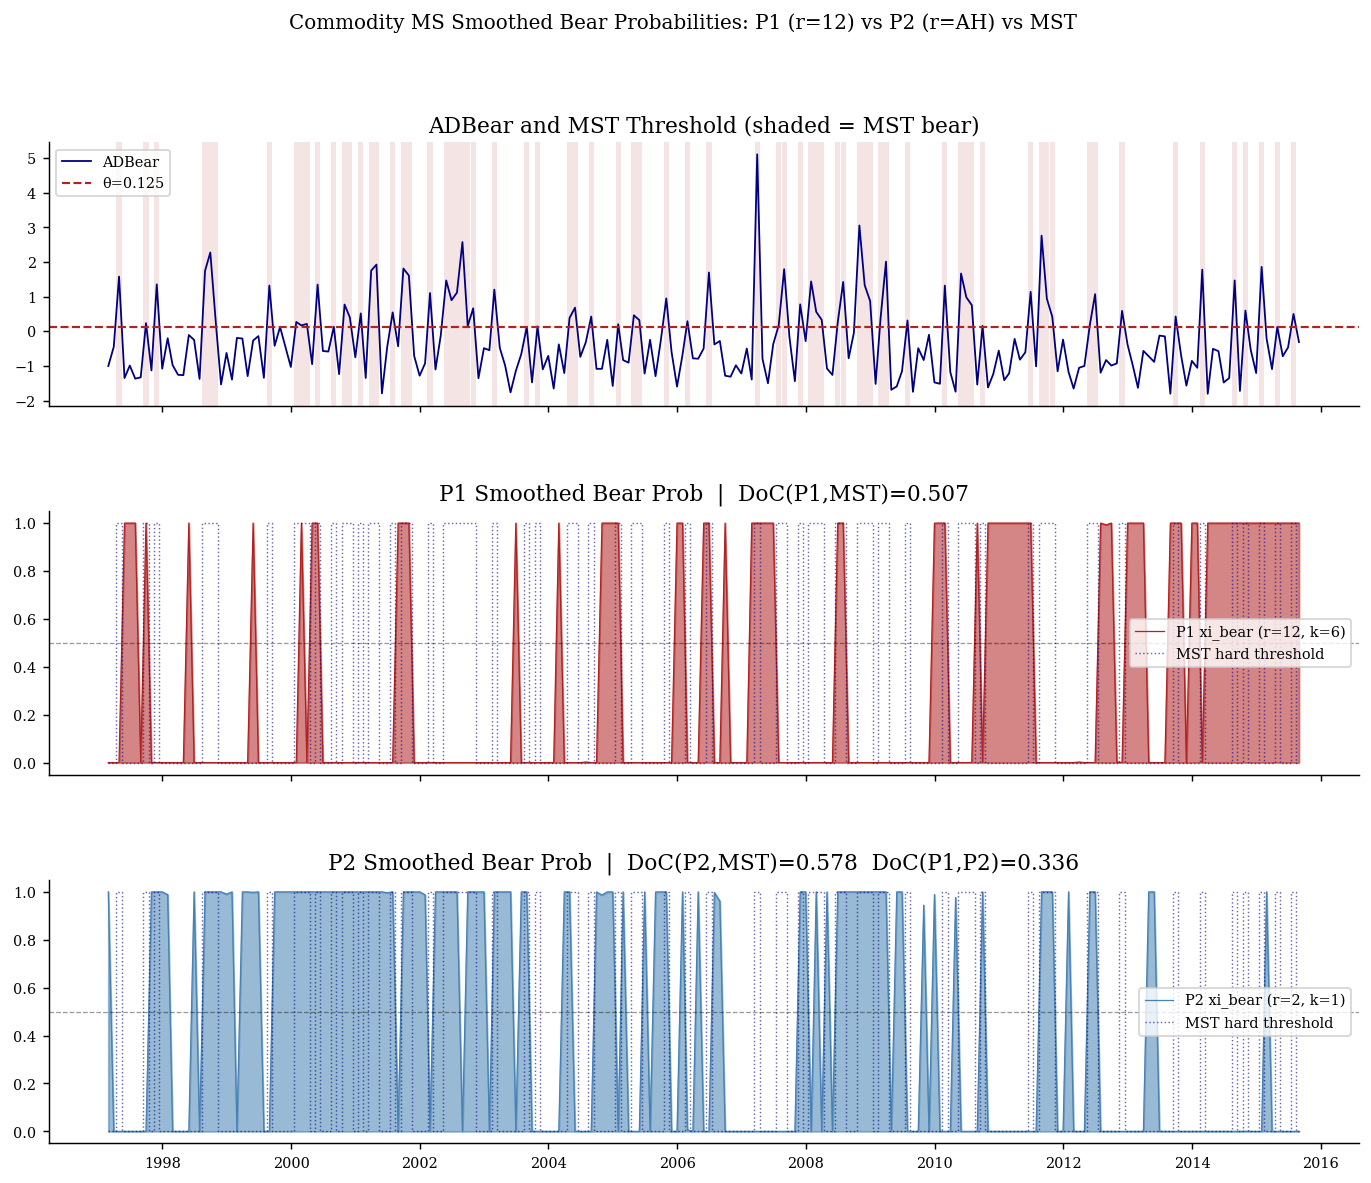

Saved fig_commodity_ms_regime_comparison.png


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.subplots_adjust(hspace=0.4)

# Panel 1: MST ADBear threshold
ax = axes[0]
ax.plot(dates, adb, color='navy', lw=1.0, label='ADBear')
ax.axhline(THETA_HAT, color='firebrick', ls='--', lw=1.2, label=f'θ={THETA_HAT}')
for t in range(T):
    if bear_mst[t]:
        ax.axvspan(dates[t]-pd.DateOffset(days=15), dates[t]+pd.DateOffset(days=15),
                   alpha=0.12, color='firebrick', lw=0)
ax.set_title('ADBear and MST Threshold (shaded = MST bear)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Panel 2: Pipeline 1 smoothed probabilities
ax = axes[1]
ax.fill_between(dates, xi_bear_p1, alpha=0.55, color='firebrick')
ax.plot(dates, xi_bear_p1, lw=0.7, color='firebrick',
        label=f'P1 xi_bear (r={R_TOTAL_P1}, k={K_P1})')
ax.step(dates, bear_mst, where='mid', color='navy', lw=0.8, ls=':', alpha=0.6,
        label='MST hard threshold')
ax.axhline(0.5, color='black', ls='--', lw=0.7, alpha=0.4)
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'P1 Smoothed Bear Prob  |  DoC(P1,MST)={DoC_p1:.3f}')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Panel 3: Pipeline 2 smoothed probabilities
ax = axes[2]
ax.fill_between(dates, xi_bear_p2, alpha=0.55, color='steelblue')
ax.plot(dates, xi_bear_p2, lw=0.7, color='steelblue',
        label=f'P2 xi_bear (r={R_TOTAL_P2}, k={K_P2})')
ax.step(dates, bear_mst, where='mid', color='navy', lw=0.8, ls=':', alpha=0.6,
        label='MST hard threshold')
ax.axhline(0.5, color='black', ls='--', lw=0.7, alpha=0.4)
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'P2 Smoothed Bear Prob  |  DoC(P2,MST)={DoC_p2:.3f}  '
             f'DoC(P1,P2)={DoC_p1p2:.3f}')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Commodity MS Smoothed Bear Probabilities: P1 (r=12) vs P2 (r=AH) vs MST',
             fontsize=11)
plt.savefig('Output/fig_commodity_ms_regime_comparison.png', bbox_inches='tight')
plt.show()
print('Saved fig_commodity_ms_regime_comparison.png')

### Figure - Cross-Sectional Fit: MST vs MS P1 vs Unconditional (2x2)

2x2 cross-sectional scatter: conditional vs unconditional per regime classifier.
Left column: y-axis = MST partition means. Right column: y-axis = MS P1 means.
Each column shows: conditional model (colour) vs unconditional (grey).
Shared axis limits across all four panels.

Requires in scope:
  X, d_D, d_S, N_FACTORS, N, T_D, T_S
  B_D, B_S, gamma_D, gamma_S          : MST Pass 2
  B1_p1, B2_p1, xi_bear_p1, xi_bull_p1: MS P1 EM outputs
  B_unc, gamma_unc                     : unconditional model (from import cell)
  mst_demean, mst_gamma, compute_rmspe : native functions
  pipeline_pass2                       : native function


Left column (MST partition y-axis):
  Bear: MST=0.771 (exp 0.771)  MS P1=0.812 (exp ~0.812)  Unc=-1.366 (exp -1.366)
  Bull: MST=0.920 (exp 0.920)  MS P1=0.931               Unc=0.644 (exp  0.644)
Right column (MS P1 partition y-axis):
  Bear: MS P1=0.810 (exp 0.810)  Unc=0.634
  Bull: MS P1=0.738 (exp 0.738)  Unc=0.675


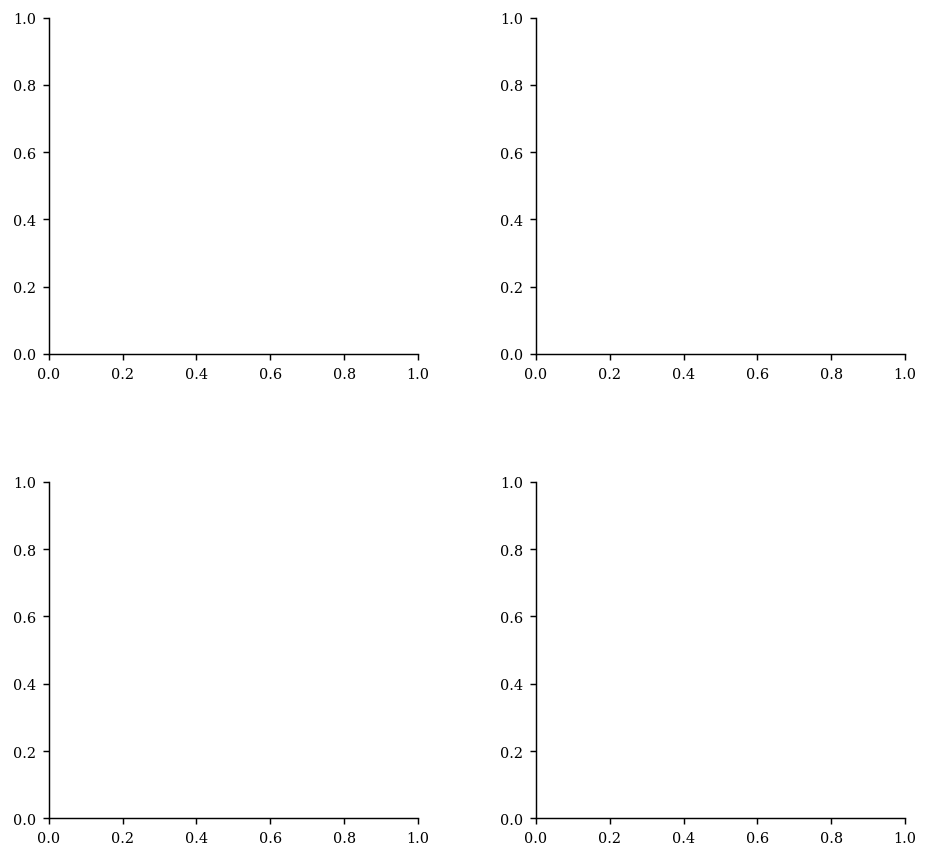

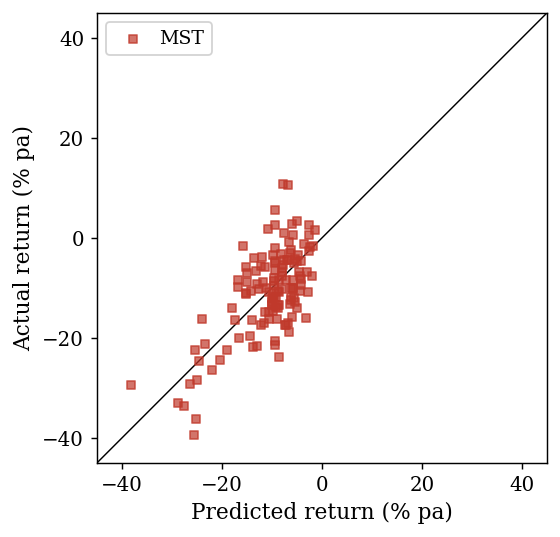

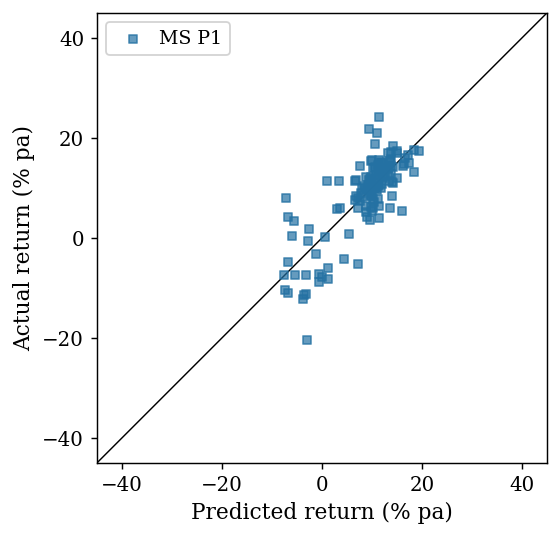

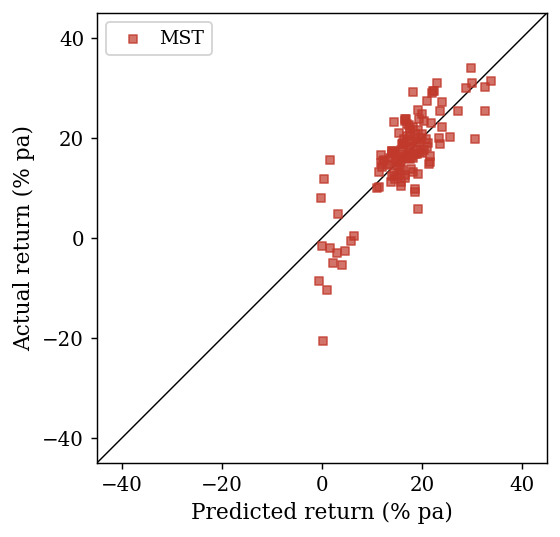

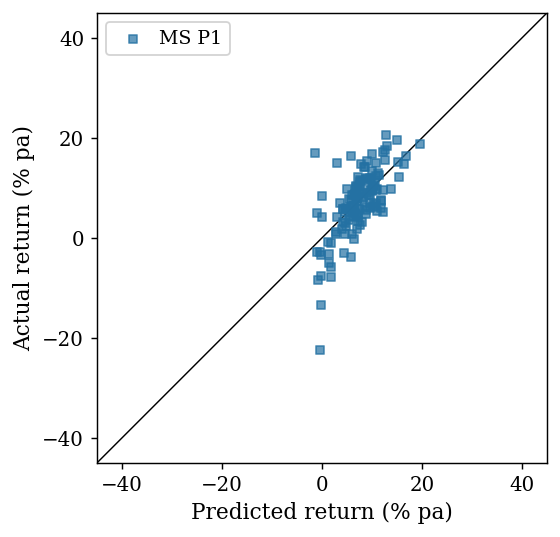

Saved.


In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

k     = N_FACTORS   # 6
scale = 1200        # monthly decimal → %pa

# Actual means
_, X_D_mst = mst_demean(X, d_D)   # (N,) MST bear-partition actual means
_, X_S_mst = mst_demean(X, d_S)   # (N,) MST bull-partition actual means

p2         = pipeline_pass2(X, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1, k, N)
X_D_ms     = p2['RD']              # (N,) MS P1 bear actual means (prob-weighted)
X_S_ms     = p2['RS']              # (N,) MS P1 bull actual means

# Conditional predicted returns
# MST: its own predicted returns
pred_mst_D = B_D[:, :k] @ gamma_D[:k]
pred_mst_S = B_S[:, :k] @ gamma_S[:k]

# MS P1 on MST partition (re-estimated gamma using MST months + MS P1 loadings)
def normalise(B, k_):
    cn = np.sqrt((B[:, :k_]**2).sum(0) / N)
    cn = np.where(cn > 1e-10, cn, 1.0)
    return B[:, :k_] / cn[None, :]

B_bear = normalise(B1_p1, k)   # bear loadings after EM permutation
B_bull = normalise(B2_p1, k)   # bull loadings

gamma_ms_D_mst = mst_gamma(X * d_D[:, None], B_bear, k, T_D)
gamma_ms_S_mst = mst_gamma(X * d_S[:, None], B_bull, k, T_S)
pred_ms_D_mst  = B_bear @ gamma_ms_D_mst   # MS P1 scored on MST partition
pred_ms_S_mst  = B_bull @ gamma_ms_S_mst

# MS P1 on its own partition (from pipeline_pass2)
pred_ms_D_own  = p2['predD']
pred_ms_S_own  = p2['predS']

# Unconditional predicted returns (same vector for all panels)
pred_unc = B_unc[:, :k] @ gamma_unc[:k]   # (N,)

# Adjusted R^2
def adjr2(actual, pred, N, k):
    rmspe = np.sqrt(((actual - pred)**2).mean())
    r2    = 1 - N * rmspe**2 / (actual @ actual)
    return 1 - (1 - r2) * N / (N - k)

# Left column (MST partition y-axis)
ar2_mst_D    = adjr2(X_D_mst, pred_mst_D,    N, k)
ar2_mst_S    = adjr2(X_S_mst, pred_mst_S,    N, k)
ar2_ms_D_mst = adjr2(X_D_mst, pred_ms_D_mst, N, k)
ar2_ms_S_mst = adjr2(X_S_mst, pred_ms_S_mst, N, k)
ar2_unc_D_mst= adjr2(X_D_mst, pred_unc,      N, k)
ar2_unc_S_mst= adjr2(X_S_mst, pred_unc,      N, k)

# Right column (MS P1 partition y-axis)
ar2_ms_D_own = adjr2(X_D_ms,  pred_ms_D_own, N, k)
ar2_ms_S_own = adjr2(X_S_ms,  pred_ms_S_own, N, k)
ar2_unc_D_ms = adjr2(X_D_ms,  pred_unc,      N, k)
ar2_unc_S_ms = adjr2(X_S_ms,  pred_unc,      N, k)
ar2_mst_D_ms = adjr2(X_D_ms,  pred_mst_D,    N, k)
ar2_mst_S_ms = adjr2(X_S_ms,  pred_mst_S,    N, k)

print('Left column (MST partition y-axis):')
print(f'  Bear: MST={ar2_mst_D:.3f} (exp 0.771)  MS P1={ar2_ms_D_mst:.3f} (exp ~0.812)  Unc={ar2_unc_D_mst:.3f} (exp -1.366)')
print(f'  Bull: MST={ar2_mst_S:.3f} (exp 0.920)  MS P1={ar2_ms_S_mst:.3f}               Unc={ar2_unc_S_mst:.3f} (exp  0.644)')
print('Right column (MS P1 partition y-axis):')
print(f'  Bear: MS P1={ar2_ms_D_own:.3f} (exp 0.810)  Unc={ar2_unc_D_ms:.3f}')
print(f'  Bull: MS P1={ar2_ms_S_own:.3f} (exp 0.738)  Unc={ar2_unc_S_ms:.3f}')

# Global axis limits
all_vals = np.concatenate([
    pred_mst_D, pred_mst_S, pred_ms_D_mst, pred_ms_S_mst,
    pred_ms_D_own, pred_ms_S_own, pred_unc,
    X_D_mst, X_S_mst, X_D_ms, X_S_ms
]) * scale
p2_lo = np.percentile(all_vals, 1)
p2_hi = np.percentile(all_vals, 99)
pad   = (p2_hi - p2_lo) * 0.06
g_lo, g_hi = -45, 45

# Plot
C_MST = '#C0392B'
C_MS  = '#2471A3'
C_UNC = '#7F8C8D'
ALPHA_COND = 0.70
ALPHA_UNC  = 0.35
MS_SZ = 18
FONT  = 12

fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.0))
fig.subplots_adjust(hspace=0.38, wspace=0.32)

panels = [
    (X_D_mst, pred_mst_D,    ar2_mst_D,    C_MST, 's', 'MST',   'fig_cs_mst_bear'),
    (X_D_ms,  pred_ms_D_own, ar2_ms_D_own, C_MS,  's', 'MS P1', 'fig_cs_ms_bear'),
    (X_S_mst, pred_mst_S,    ar2_mst_S,    C_MST, 's', 'MST',   'fig_cs_mst_bull'),
    (X_S_ms,  pred_ms_S_own, ar2_ms_S_own, C_MS,  's', 'MS P1', 'fig_cs_ms_bull'),
]

for actual, cond_pred, cond_r2, col, mkr, cond_lbl, fname in panels:
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

    a  = actual    * scale
    cp = cond_pred * scale

    ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
    ax.scatter(cp, a, color=col, marker=mkr, s=MS_SZ, alpha=ALPHA_COND,
               zorder=2, label=cond_lbl)

    ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
    ax.set_aspect('equal')
    ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
    ax.set_ylabel('Actual return (% pa)',    fontsize=FONT)
    #ax.set_title(title, fontsize=FONT + 1, fontweight='bold')
    ax.tick_params(labelsize=FONT - 1)
    ax.legend(fontsize=FONT - 1.5, framealpha=0.85,
              loc='upper left', handletextpad=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    plt.savefig(f'Output/{fname}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'Output/{fname}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

print('Saved.')


### Figure - Conditional (MST) vs Unconditional Fit, Bear and Bull

Two single-panel scatterplots (saved separately): realised vs predicted
returns for the MST conditional model against the unconditional benchmark,
one panel per regime.


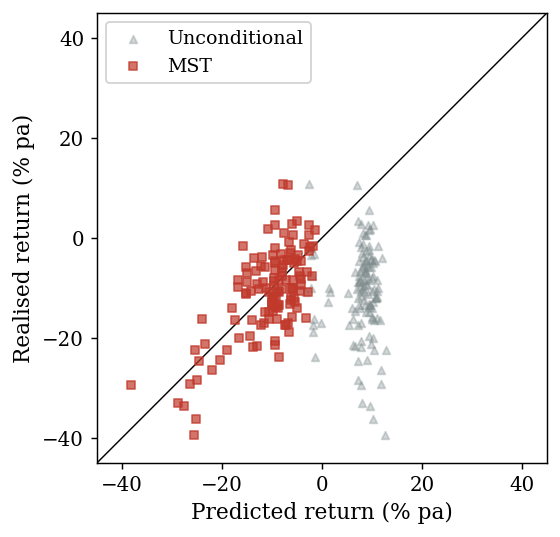

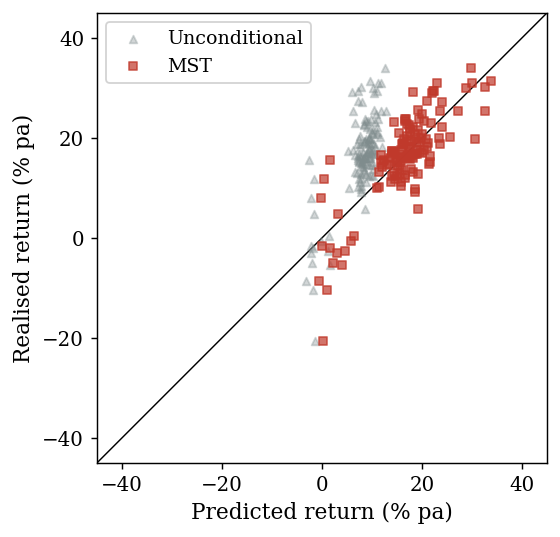

In [26]:
# Bear panel
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

a  = X_D_mst   * scale
cp = pred_mst_D * scale
up = pred_unc   * scale

ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
ax.scatter(up, a, color=C_UNC, marker='^', s=MS_SZ, alpha=ALPHA_UNC,
           zorder=1, label='Unconditional')
ax.scatter(cp, a, color=C_MST, marker='s', s=MS_SZ, alpha=ALPHA_COND,
           zorder=2, label='MST')

ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
ax.set_aspect('equal')
ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
ax.set_ylabel('Realised return (% pa)',    fontsize=FONT)
#ax.set_title('Whole sample, Bear ($D$) regime', fontsize=FONT + 1, fontweight='bold')
ax.tick_params(labelsize=FONT - 1)
ax.legend(fontsize=FONT - 1.5, framealpha=0.85, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.savefig('Output/fig_mst_cond_vs_unc_bear.png', bbox_inches='tight', dpi=300)
plt.savefig('Output/fig_mst_cond_vs_unc_bear.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Bull panel
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

a  = X_S_mst   * scale
cp = pred_mst_S * scale
up = pred_unc   * scale

ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
ax.scatter(up, a, color=C_UNC, marker='^', s=MS_SZ, alpha=ALPHA_UNC,
           zorder=1, label='Unconditional')
ax.scatter(cp, a, color=C_MST, marker='s', s=MS_SZ, alpha=ALPHA_COND,
           zorder=2, label='MST')

ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
ax.set_aspect('equal')
ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
ax.set_ylabel('Realised return (% pa)',    fontsize=FONT)
#ax.set_title('Whole sample, Bull ($S$) regime', fontsize=FONT + 1, fontweight='bold')
ax.tick_params(labelsize=FONT - 1)
ax.legend(fontsize=FONT - 1.5, framealpha=0.85, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.savefig('Output/fig_mst_cond_vs_unc_bull.png', bbox_inches='tight', dpi=300)
plt.savefig('Output/fig_mst_cond_vs_unc_bull.pdf', bbox_inches='tight', dpi=300)
plt.show()

---
# Comprehensive Regime Analysis

All analyses use **Pipeline 1 (r_total=12, k=6)** as the primary specification
since it is directly comparable to the MST benchmark and is the thesis headline result.
Pipeline 2 comparisons are shown where the contrast adds insight.

In [27]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

C_MST, C_P1, C_P2, C_OIL = '#4A6FA5', '#B23A48', '#2CA02C', '#D98C2B'
C_BOTH, C_P1ONLY, C_P2ONLY = '#8B0000', '#FF8C00', '#1E90FF'

crisis_windows = [
    ('1997-07','1998-12','Asian crisis\n+ LTCM\n1997-98'),
    ('2001-03','2001-11','Dot-com\nrecession\n2001'),
    ('2008-07','2009-03','Global\nfinancial crisis\n2008-09'),
    ('2011-05','2011-10','Euro debt /\ncommodity peak\n2011'),
    ('2014-06','2015-08','Oil price\ncollapse\n2014-15'),
]

# Bear indicator arrays for both pipelines
in_bear_p1 = bear_p1
in_bear_p2 = bear_p2

# Pricing arrays from both pipelines
kk_p1 = df_p1.index.values
kk_p2 = df_p2.index.values
mst_bear_rmspe = (df_p1['mst_D_rmspe']*12*100).values
p1_bear_rmspe  = (df_p1['ms_D_rmspe']*12*100).values
mst_bull_rmspe = (df_p1['mst_S_rmspe']*12*100).values
p1_bull_rmspe  = (df_p1['ms_S_rmspe']*12*100).values
mst_bear_r2 = df_p1['mst_D_adjr2'].values
p1_bear_r2  = df_p1['ms_D_adjr2'].values
mst_bull_r2 = df_p1['mst_S_adjr2'].values
p1_bull_r2  = df_p1['ms_S_adjr2'].values
p2_bear_rmspe = (df_p2['ms_D_rmspe']*12*100).values
p2_bull_rmspe = (df_p2['ms_S_rmspe']*12*100).values
p2_bear_r2 = df_p2['ms_D_adjr2'].values
p2_bull_r2 = df_p2['ms_S_adjr2'].values

print('Figure setup complete.')
print(f'P1 arrays: k={kk_p1}, P2 arrays: k={kk_p2}')

Figure setup complete.
P1 arrays: k=[1 2 3 4 5 6], P2 arrays: k=[1]


---
## Regime Narrative - Episode Dating and Crisis Coverage

In [28]:
# P1 bear episodes
episodes_p1 = []
start = None
for t in range(T):
    if in_bear_p1[t]==1 and start is None: start=t
    elif in_bear_p1[t]==0 and start is not None:
        episodes_p1.append((start,t-1)); start=None
if start is not None: episodes_p1.append((start,T-1))

print('='*70)
print('P1 BEAR EPISODES (xi_bear_p1 >= 0.5, r_total=12)')
print('='*70)
print(f'{"Start":>10}  {"End":>10}  {"Months":>7}  {"Peak xi":>8}  {"Mean ret %pa":>12}')
print('-'*55)
for s, e in episodes_p1:
    span = dates[s:e+1]
    peak = xi_bear_p1[s:e+1].max()
    ret  = X[s:e+1].mean()*12*100
    print(f'{span[0].strftime("%Y-%m"):>10}  {span[-1].strftime("%Y-%m"):>10}  '
          f'{e-s+1:>7}  {peak:>8.3f}  {ret:>12.2f}')

# P2 bear episodes
episodes_p2 = []
start = None
for t in range(T):
    if in_bear_p2[t]==1 and start is None: start=t
    elif in_bear_p2[t]==0 and start is not None:
        episodes_p2.append((start,t-1)); start=None
if start is not None: episodes_p2.append((start,T-1))

print(f'\nP1 total bear episodes: {len(episodes_p1)}')
print(f'P2 total bear episodes: {len(episodes_p2)}')

# Crisis window coverage
print(f'\n{"="*70}')
print('CRISIS WINDOW COVERAGE')
print(f'{"Crisis":45}  {"P1 cover":>10}  {"P2 cover":>10}  {"MST cover":>10}')
print('='*70)
crises_full = [
    ('1997-07','1998-12','Asian financial crisis + LTCM/Russia'),
    ('2001-03','2001-11','Dot-com recession'),
    ('2008-07','2009-03','Global financial crisis + commodity crash'),
    ('2011-05','2011-10','European debt crisis / commodity peak'),
    ('2014-06','2015-08','Oil price collapse (WTI $107 to $40)'),
]
for cs, ce, label in crises_full:
    cs_d = pd.Timestamp(cs)+pd.offsets.MonthEnd(0)
    ce_d = pd.Timestamp(ce)+pd.offsets.MonthEnd(0)
    mask = (dates>=cs_d)&(dates<=ce_d)
    if mask.sum()==0: continue
    p1_cov = in_bear_p1[mask].mean()*100
    p2_cov = in_bear_p2[mask].mean()*100
    mst_cov = bear_mst[mask].mean()*100
    print(f'  {label[:43]:<43}  {p1_cov:>9.0f}%  {p2_cov:>9.0f}%  {mst_cov:>9.0f}%')

print(f'\nOverall MS vs MST agreement [P1]:')
print(f'  MST bear months: {int(d_D.sum())}')
print(f'  P1  bear months: {int(in_bear_p1.sum())}')
print(f'  P2  bear months: {int(in_bear_p2.sum())}')
print(f'  P1 captures {((in_bear_p1==1)&(d_D==1)).sum()/d_D.sum():.0%} of MST bear months')
print(f'  P2 captures {((in_bear_p2==1)&(d_D==1)).sum()/d_D.sum():.0%} of MST bear months')

P1 BEAR EPISODES (xi_bear_p1 >= 0.5, r_total=12)
     Start         End   Months   Peak xi  Mean ret %pa
-------------------------------------------------------
   1997-05     1997-07        3     1.000         53.50
   1997-09     1997-09        1     1.000         30.44
   1998-05     1998-05        1     1.000        -33.96
   1999-05     1999-05        1     1.000         14.22
   2000-02     2000-02        1     1.000        -58.32
   2000-04     2000-05        2     1.000         45.89
   2001-08     2001-10        3     1.000        -14.83
   2003-06     2003-06        1     1.000         29.58
   2004-02     2004-02        1     1.000         30.11
   2004-10     2005-01        4     1.000         16.57
   2005-12     2006-01        2     1.000         30.46
   2006-05     2006-06        2     1.000        -27.71
   2006-09     2006-09        1     1.000        -14.98
   2007-02     2007-06        5     1.000         15.00
   2008-06     2008-07        2     1.000        -44.11

---
## Figure 4 - Crisis Coverage: P1 vs P2 vs MST

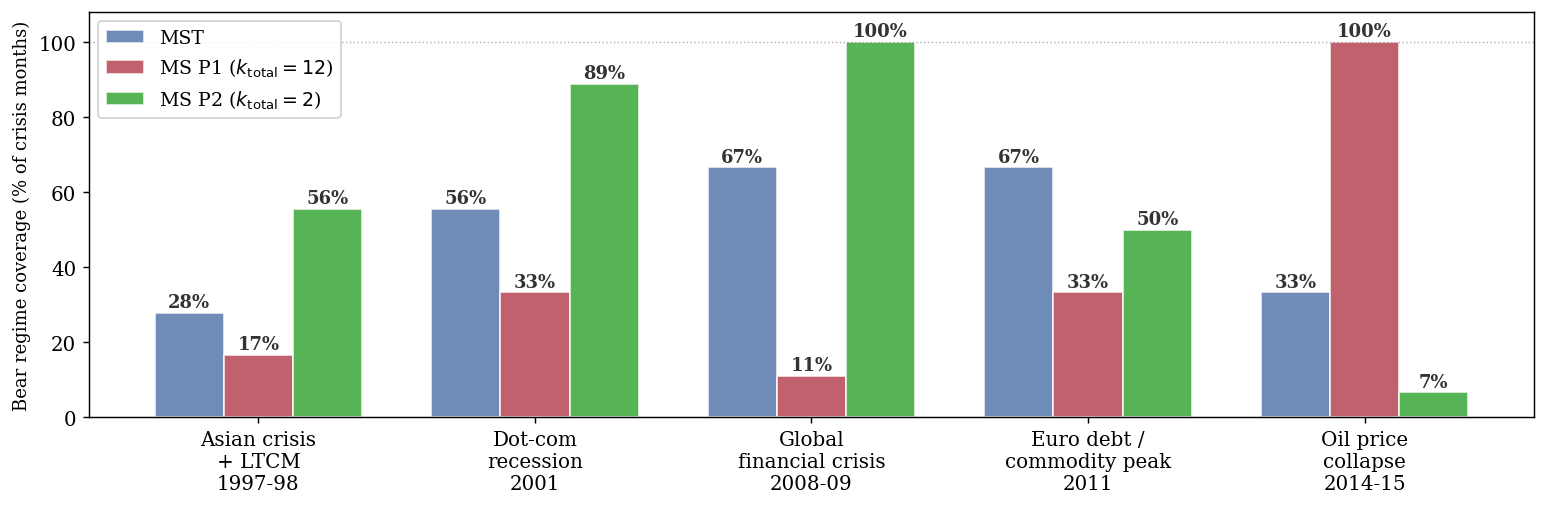

Saved Output/fig4_crisis_coverage.pdf


In [29]:
labels_cw, cover_p1, cover_p2, cover_mst = [], [], [], []
for cs, ce, lbl in crisis_windows:
    mask = ((dates>=pd.Timestamp(cs)+pd.offsets.MonthEnd(0)) &
            (dates<=pd.Timestamp(ce)+pd.offsets.MonthEnd(0)))
    labels_cw.append(lbl)
    cover_p1.append(in_bear_p1[mask].mean()*100 if mask.sum()>0 else 0)
    cover_p2.append(in_bear_p2[mask].mean()*100 if mask.sum()>0 else 0)
    cover_mst.append(bear_mst[mask].mean()*100  if mask.sum()>0 else 0)

x = np.arange(len(labels_cw)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 4))
b1 = ax.bar(x-w,   cover_mst, w, color=C_MST, alpha=0.8, label='MST', edgecolor='white')
b2 = ax.bar(x,   cover_p1, w, color=C_P1, alpha=0.8,
            label=f'MS P1 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P1}$)', edgecolor='white')
b3 = ax.bar(x+w, cover_p2, w, color=C_P2, alpha=0.8,
            label=f'MS P2 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P2}$)', edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1.5, f'{h:.0f}%',
                ha='center', fontsize=10, fontweight='bold', color='#333')
ax.set_xticks(x); ax.set_xticklabels(labels_cw, fontsize=8.5)
ax.set_ylabel('Bear regime coverage (% of crisis months)')
ax.set_ylim(0, 108); 
#ax.set_title('Crisis coverage: MST vs MS Pipeline 1 vs MS Pipeline 2', fontsize=11)
ax.axhline(100, color='gray', ls=':', lw=0.8, alpha=0.6)
ax.tick_params(labelsize=FONT - 1)
ax.legend(fontsize=FONT - 1.5, framealpha=0.85, loc='upper left')
ax.grid(axis='y', alpha=0.2, lw=0.5)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.tight_layout()
plt.savefig('Output/fig4_crisis_coverage.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('Saved Output/fig4_crisis_coverage.pdf')

---
## Figure 6 - Regime Probability Timeline

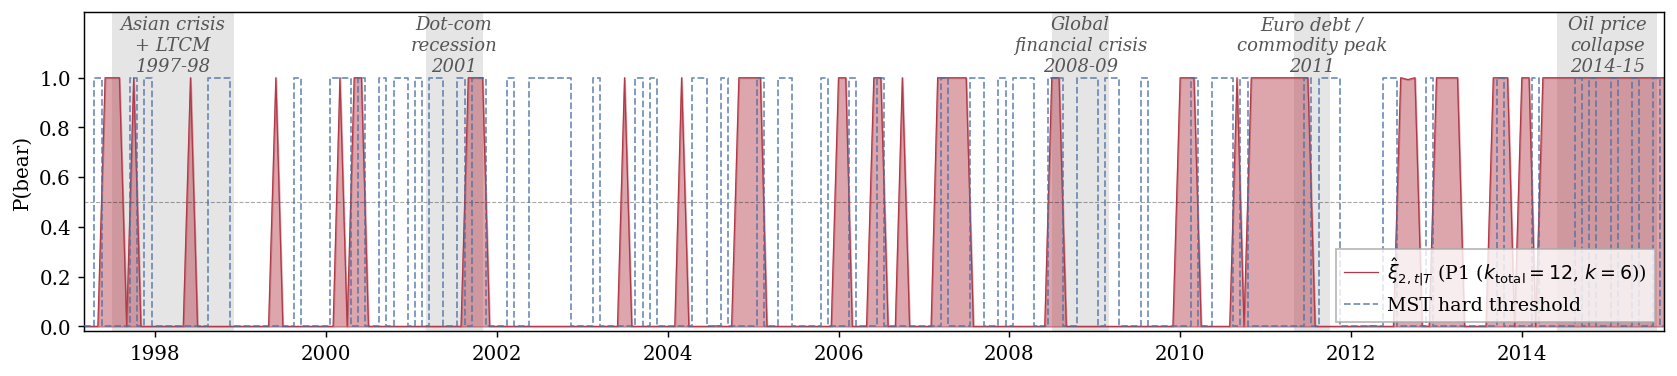

Saved fig6_p1_timeline


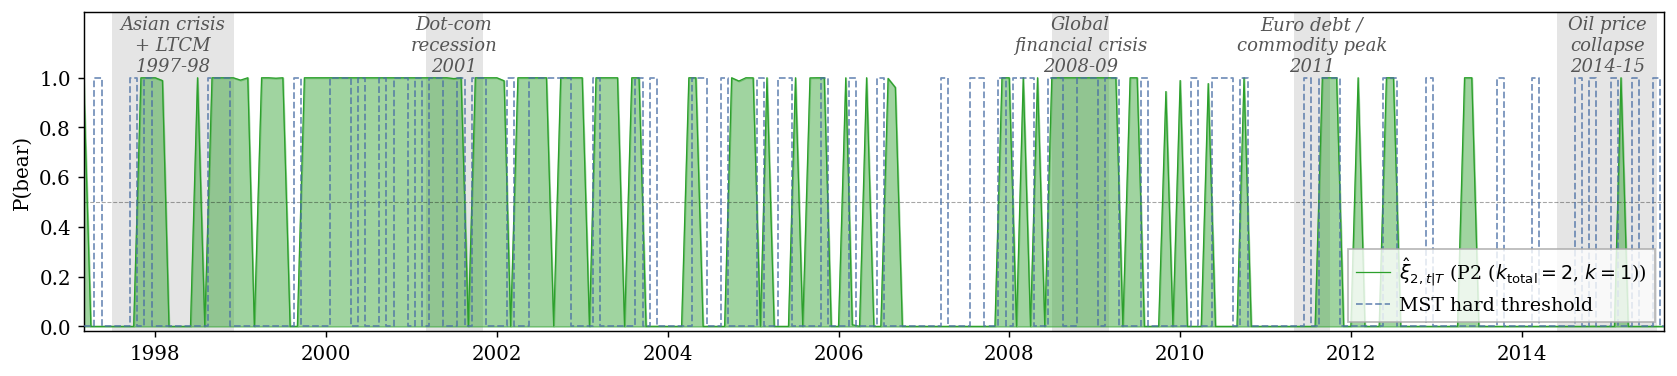

Saved fig6_p2_timeline


In [30]:
import matplotlib.dates as mdates

for panel_idx, (xi_, label, color, fname) in enumerate([
    (xi_bear_p1, f'P1 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P1}$, $k={K_P1}$)', C_P1, 'fig6_p1_timeline'),
    (xi_bear_p2, f'P2 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P2}$, $k={K_P2}$)', C_P2, 'fig6_p2_timeline'),
]):
    fig, ax = plt.subplots(1, 1, figsize=(13, 3))

    # Crisis shading + centred labels
    for cs, ce, lbl in crisis_windows:
        t_start = pd.Timestamp(cs)
        t_end   = pd.Timestamp(ce)
        t_mid   = t_start + (t_end - t_start) / 2
        ax.axvspan(t_start, t_end, alpha=0.2, color='gray', lw=0, zorder=0)
        ax.text(t_mid, 1.01, lbl, ha='center', va='bottom',
                fontsize=FONT - 2, color='#555', style='italic')

    # Filled probability area
    ax.fill_between(dates, xi_, alpha=0.45, color=color, zorder=1)
    ax.plot(dates, xi_, lw=0.7, color=color,
            label=r'$\hat{\xi}_{2,t|T}$ ' + f'({label})', zorder=2)

    # MST threshold - dashed
    ax.step(dates, bear_mst, where='mid',
            color=C_MST, lw=1.0, alpha=0.75,
            ls='--', label='MST hard threshold', zorder=3)

    # 0.5 decision line
    ax.axhline(0.5, color='black', ls='--', lw=0.6, alpha=0.35, zorder=1)

    n_int = ((xi_ > 0.05) & (xi_ < 0.95)).sum()
    ax.set_ylim(-0.02, 1.263)
    ax.set_ylabel('P(bear)', fontsize=FONT - 1)
    '''
    ax.set_title(
        f'{label}\u2002|\u2002Interior = {n_int}/{T} ({n_int/T:.1%})',
        fontsize=9.5, pad=6
    )
    '''
    ax.tick_params(axis='x', labelsize=FONT - 1)
    ax.tick_params(axis='y', labelsize=FONT - 1)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(dates.min(), dates.max())

    # Box + no grid
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    # Legend - boxed with default (light) edge, not black
    ax.legend(frameon=True, fontsize= FONT - 1.5, loc='lower right',
              fancybox=False, edgecolor='#aaaaaa',
              handlelength=1.8, handletextpad=0.5)

    plt.tight_layout()
    plt.savefig(f'Output/{fname}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'Output/{fname}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Saved {fname}')

---
## Figure 7 - Pass 2 Cross-Sectional Fit (P1)

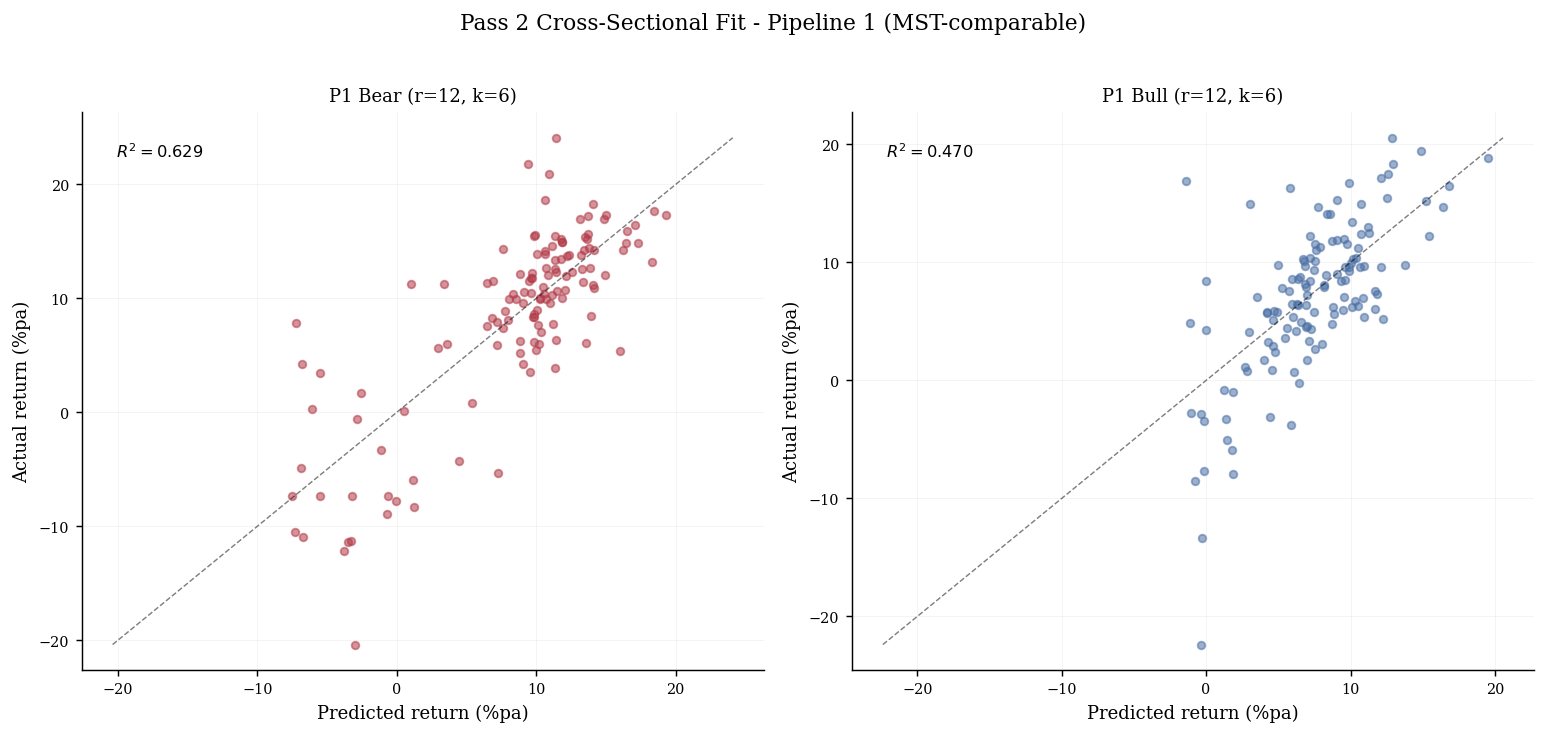

Saved Output/fig7_crosssection_p1.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, pred, actual, rbar, col, title in [
    (axes[0], p2_p1['predD'], p2_p1['RD'], X_D_mean, C_P1,  'P1 Bear (r=12, k=6)'),
    (axes[1], p2_p1['predS'], p2_p1['RS'], X_S_mean, C_MST, 'P1 Bull (r=12, k=6)'),
]:
    ax.scatter(pred*12*100, actual*12*100, color=col, s=18, alpha=0.55)
    lo=min(pred.min(),actual.min())*12*100
    hi=max(pred.max(),actual.max())*12*100
    ax.plot([lo,hi],[lo,hi],'k--',lw=0.8,alpha=0.5)
    ss_res=((actual-pred)**2).sum(); ss_tot=((actual-actual.mean())**2).sum()
    r2=1-ss_res/(ss_tot+1e-30)
    ax.text(0.05,0.92,f'$R^2={r2:.3f}$',transform=ax.transAxes,fontsize=9)
    ax.set_xlabel('Predicted return (%pa)'); ax.set_ylabel('Actual return (%pa)')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.15, lw=0.5)

fig.suptitle('Pass 2 Cross-Sectional Fit - Pipeline 1 (MST-comparable)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('Output/fig7_crosssection_p1.png', bbox_inches='tight', facecolor='white')
plt.show()
print('Saved Output/fig7_crosssection_p1.png')

---
## NW t-Statistics Summary - Both Pipelines

In [32]:
print('='*95)
print('NW t-STATISTICS SUMMARY - P1 (k=6) and P2 (k=2)')
print('='*95)

print(f'\nP1 Bear regime (r_total={R_TOTAL_P1}, k={K_P1}):')
print(f'  {"Factor":<10} {"MST est%pa [t]":>20} {"MS est%pa [t]":>20}')
print('  '+'-'*52)
for j in range(K_P1):
    print(f'  gamma_{j+1:<4} {gb_D[j]*12*100:>8.3f}% [{t_D[j]:>5.2f}]'
          f'  {p2_p1["gbD"][j]*12*100:>8.3f}% [{p2_p1["tD"][j]:>5.2f}]')

print(f'\nP1 Bull regime (r_total={R_TOTAL_P1}, k={K_P1}):')
print(f'  {"Factor":<10} {"MST est%pa [t]":>20} {"MS est%pa [t]":>20}')
print('  '+'-'*52)
for j in range(K_P1):
    print(f'  gamma_{j+1:<4} {gb_S[j]*12*100:>8.3f}% [{t_S[j]:>5.2f}]'
          f'  {p2_p1["gbS"][j]*12*100:>8.3f}% [{p2_p1["tS"][j]:>5.2f}]')

print(f'\nP2 Bear regime (r_total={R_TOTAL_P2}, k={K_P2}):')
print(f'  {"Factor":<10} {"MST est%pa [t]":>20} {"MS est%pa [t]":>20}')
print('  '+'-'*52)
for j in range(K_P2):
    print(f'  gamma_{j+1:<4} {gb_D[j]*12*100:>8.3f}% [{t_D[j]:>5.2f}]'
          f'  {p2_p2["gbD"][j]*12*100:>8.3f}% [{p2_p2["tD"][j]:>5.2f}]')

print(f'\nP2 Bull regime (r_total={R_TOTAL_P2}, k={K_P2}):')
print(f'  {"Factor":<10} {"MST est%pa [t]":>20} {"MS est%pa [t]":>20}')
print('  '+'-'*52)
for j in range(K_P2):
    print(f'  gamma_{j+1:<4} {gb_S[j]*12*100:>8.3f}% [{t_S[j]:>5.2f}]'
          f'  {p2_p2["gbS"][j]*12*100:>8.3f}% [{p2_p2["tS"][j]:>5.2f}]')

NW t-STATISTICS SUMMARY - P1 (k=6) and P2 (k=2)

P1 Bear regime (r_total=12, k=6):
  Factor           MST est%pa [t]        MS est%pa [t]
  ----------------------------------------------------
  gamma_1     -11.562% [-1.53]    -7.399% [-3.87]
  gamma_2      -0.985% [-0.37]    -5.276% [-7.37]
  gamma_3      -0.332% [-0.17]    -5.051% [-8.22]
  gamma_4       3.662% [ 1.91]    -0.724% [-1.87]
  gamma_5       0.661% [ 0.43]    -0.570% [-1.48]
  gamma_6      -1.795% [-1.42]    -1.829% [-5.21]

P1 Bull regime (r_total=12, k=6):
  Factor           MST est%pa [t]        MS est%pa [t]
  ----------------------------------------------------
  gamma_1      17.140% [ 5.07]    -8.112% [-2.34]
  gamma_2       3.960% [ 1.93]     0.032% [ 0.02]
  gamma_3       1.408% [ 1.21]    -1.101% [-1.23]
  gamma_4      -1.460% [-1.51]     1.588% [ 2.13]
  gamma_5       1.706% [ 2.08]     0.528% [ 0.97]
  gamma_6      -0.589% [-0.83]    -0.745% [-1.07]

P2 Bear regime (r_total=2, k=1):
  Factor           MST est%p

---
## Pass 3 - Observable Factor Premia: P1 vs P2 vs MST

In [33]:
theory = {'BM':'+ (value)','MOM':'- (reversal)','HP':'+ (hedging)','BASIS':'+ (backw.)'}

print('='*85)
print('PASS 3 ROTATED RISK PREMIA (annualised %pa)')
print('='*85)
print(f'  {"Factor":<8}  {"MST Bear":>10}  {"P1 Bear":>10}  {"P2 Bear":>10}  '
      f'{"MST Bull":>10}  {"P1 Bull":>10}  {"P2 Bull":>10}  Theory')
print('  '+'-'*82)
for i, fn in enumerate(factor_names[:4]):
    gDmst = gD_mst_p1[i]*12*100 if i<len(gD_mst_p1) else np.nan
    gSmst = gS_mst_p1[i]*12*100 if i<len(gS_mst_p1) else np.nan
    gDp1  = gD_ms_p1[i]*12*100  if i<len(gD_ms_p1)  else np.nan
    gSp1  = gS_ms_p1[i]*12*100  if i<len(gS_ms_p1)  else np.nan
    gDp2  = gD_ms_p2[i]*12*100  if i<len(gD_ms_p2)  else np.nan
    gSp2  = gS_ms_p2[i]*12*100  if i<len(gS_ms_p2)  else np.nan
    print(f'  {fn:<8}  {gDmst:>10.2f}  {gDp1:>10.2f}  {gDp2:>10.2f}  '
          f'{gSmst:>10.2f}  {gSp1:>10.2f}  {gSp2:>10.2f}  {theory.get(fn,"")}')

print()
print('Note: P2 Pass 3 uses only k=2 latent factors - underdetermined 4×2 rotation.')
print('P1 Pass 3 (k=6) is the preferred specification for economic interpretation.')
print('MOM and HP signs are most robust across specifications.')

PASS 3 ROTATED RISK PREMIA (annualised %pa)
  Factor      MST Bear     P1 Bear     P2 Bear    MST Bull     P1 Bull     P2 Bull  Theory
  ----------------------------------------------------------------------------------
  BM            -11.83       -3.84        1.88       10.95       10.00        8.52  + (value)
  MOM            19.22       16.31       -7.16      -12.27      -11.57      -12.38  - (reversal)
  HP              3.94        4.28        0.03       -6.31       -0.74       -2.42  + (hedging)
  BASIS          -6.16       -4.28        1.20        1.94        0.83        3.74  + (backw.)

Note: P2 Pass 3 uses only k=2 latent factors - underdetermined 4×2 rotation.
P1 Pass 3 (k=6) is the preferred specification for economic interpretation.
MOM and HP signs are most robust across specifications.


In [34]:
# Formal one-sided bootstrap test: H0: gamma^g_HP,D = gamma^g_HP,S
# H1: gamma^g_HP,D > gamma^g_HP,S
# Test statistic: delta = gamma^g_HP,D - gamma^g_HP,S from Pass 3
# p-value = fraction of bootstrap draws >= observed delta (one-sided)

HP_IDX    = 2       # index of HP in ['BM','MOM','HP','BASIS']
B_BOOT_HP = 2000
RNG_SEED_HP = 19780308

def hp_bootstrap_mst(G_obs, Xdm_D, Xdm_S, B_D, B_S, d_D, d_S,
                     gamma_D, gamma_S, N, T, B_boot, rng_seed=RNG_SEED_HP):
    """
    One-sided bootstrap test for HP premium asymmetry under MST specification.
    Wild bootstrap on full return panel, pass full-panel demeaned matrix to
    pass3_mst (matching original implementation).
    """
    rng = np.random.default_rng(rng_seed)

    def _pass3_mst_full(G_obs_, Xdm_full_, B_j_, d_j_, gam_j_):
        """pass3_mst operating on full-panel Xdm (T x N), indexed by d_j_."""
        G_bar = G_obs_[d_j_==1].mean(0)
        G_dm  = G_obs_ - G_bar
        F_j   = (Xdm_full_ @ B_j_ / N)[d_j_==1]
        u     = F_j[:, :len(gam_j_)]
        num   = (G_dm[d_j_==1]).T @ u
        den   = u.T @ u + 1e-10 * np.eye(len(gam_j_))
        Lam   = num @ np.linalg.inv(den)
        return (Lam @ gam_j_).flatten()

    # Observed test statistic using existing full-panel demeaned matrices
    gD_obs_arr = _pass3_mst_full(G_obs, Xdm_D, B_D, d_D, gamma_D)
    gS_obs_arr = _pass3_mst_full(G_obs, Xdm_S, B_S, d_S, gamma_S)
    delta_obs  = gD_obs_arr[HP_IDX] - gS_obs_arr[HP_IDX]

    # Bootstrap setup
    T_D = int(d_D.sum()); T_S = int(d_S.sum())
    k   = len(gamma_D)

    F_D  = (Xdm_D @ B_D / N)[d_D==1, :k]   # (T_D, k)
    F_S  = (Xdm_S @ B_S / N)[d_S==1, :k]   # (T_S, k)
    fit_D = B_D[:, :k] @ gamma_D[:k]         # (N,)
    fit_S = B_S[:, :k] @ gamma_S[:k]         # (N,)
    com_D = F_D @ B_D[:, :k].T               # (T_D, N)
    com_S = F_S @ B_S[:, :k].T               # (T_S, N)

    X_D_reg = X[d_D==1]     # (T_D, N)
    X_S_reg = X[d_S==1]     # (T_S, N)
    err_D   = X_D_reg - fit_D[None, :] - com_D
    err_S   = X_S_reg - fit_S[None, :] - com_S

    # Zero-mean alpha under null
    a0_D = (X_D_reg.mean(0) - fit_D); a0_D -= a0_D.mean()
    a0_S = (X_S_reg.mean(0) - fit_S); a0_S -= a0_S.mean()

    FW_D = np.eye(T_D) - np.ones((T_D, T_D)) / T_D
    FW_S = np.eye(T_S) - np.ones((T_S, T_S)) / T_S

    count = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T, N))
        w_D = w[d_D==1]; w_S = w[d_S==1]

        # Bootstrap regime samples
        Xb_D = a0_D[None,:] + fit_D[None,:] + com_D + err_D * w_D  # (T_D, N)
        Xb_S = a0_S[None,:] + fit_S[None,:] + com_S + err_S * w_S  # (T_S, N)

        # Re-estimate Pass 2 loadings on bootstrap samples
        B_D_b = (Xb_D.T @ FW_D @ F_D) @ np.linalg.inv(
                  F_D.T @ FW_D @ F_D + 1e-12*np.eye(k))   # (N, k)
        B_S_b = (Xb_S.T @ FW_S @ F_S) @ np.linalg.inv(
                  F_S.T @ FW_S @ F_S + 1e-12*np.eye(k))   # (N, k)

        # Re-estimate Pass 2 risk premia
        g_D_b = np.linalg.lstsq(
            B_D_b.T @ B_D_b, B_D_b.T @ Xb_D.mean(0), rcond=None)[0]
        g_S_b = np.linalg.lstsq(
            B_S_b.T @ B_S_b, B_S_b.T @ Xb_S.mean(0), rcond=None)[0]

        # Reconstruct full-panel demeaned bootstrap matrices
        # Bear: fill bootstrap bear rows, keep bull rows at zero (for G projection)
        Xdm_D_b = np.zeros((T, N))
        Xdm_D_b[d_D==1] = Xb_D - Xb_D.mean(0)
        Xdm_S_b = np.zeros((T, N))
        Xdm_S_b[d_S==1] = Xb_S - Xb_S.mean(0)

        # Re-run Pass 3
        gD_b = _pass3_mst_full(G_obs, Xdm_D_b, B_D_b, d_D, g_D_b)
        gS_b = _pass3_mst_full(G_obs, Xdm_S_b, B_S_b, d_S, g_S_b)
        delta_b = gD_b[HP_IDX] - gS_b[HP_IDX]

        if delta_b >= delta_obs:
            count += 1

    pval = count / B_boot
    return delta_obs * 12 * 100, pval   # annualised %pa


def hp_bootstrap_ms(G_obs, X_dm, B1, B2, xi_bear, xi_bull,
                    p2_result, N, T, B_boot, rng_seed=RNG_SEED_HP):
    """
    One-sided bootstrap test for HP premium asymmetry under MS P1 specification.
    Regime assignments xi fixed from EM; bootstrap resamples return panels.
    """
    rng = np.random.default_rng(rng_seed)

    def _pass3_ms(G_obs_, B_j_, xi_j_, gam_lat_):
        k_    = len(gam_lat_)
        T_eff = xi_j_.sum()
        G_bar = (xi_j_[:,None] * G_obs_).sum(0) / T_eff
        G_dm  = G_obs_ - G_bar
        Binv  = np.linalg.inv(B_j_[:,:k_].T @ B_j_[:,:k_] / N + 1e-10*np.eye(k_))
        u     = (X_dm @ B_j_[:,:k_] / N) @ Binv.T   # (T, k_)
        num   = (xi_j_[:,None] * G_dm).T @ u
        den   = (xi_j_[:,None] * u).T @ u + 1e-10*np.eye(k_)
        Lam   = num @ np.linalg.inv(den)
        return (Lam @ gam_lat_).flatten()

    # Observed test statistic
    gD_obs_arr = _pass3_ms(G_obs, p2_result['B2n'], xi_bear, p2_result['gD'])
    gS_obs_arr = _pass3_ms(G_obs, p2_result['B1n'], xi_bull, p2_result['gS'])
    delta_obs  = gD_obs_arr[HP_IDX] - gS_obs_arr[HP_IDX]

    # Use hard partition for bootstrap residuals (consistent with pricing bootstrap)
    bear = (xi_bear >= 0.5).astype(int)
    bull = 1 - bear
    T_D  = int(bear.sum()); T_S = int(bull.sum())
    k    = len(p2_result['gD'])

    B_D  = p2_result['B2n']; B_S = p2_result['B1n']
    gD   = p2_result['gD'];  gS  = p2_result['gS']

    F_D   = (X_dm @ B_D / N)[bear==1, :k]
    F_S   = (X_dm @ B_S / N)[bull==1, :k]
    fit_D = B_D[:,:k] @ gD[:k]
    fit_S = B_S[:,:k] @ gS[:k]
    com_D = F_D @ B_D[:,:k].T
    com_S = F_S @ B_S[:,:k].T

    X_D_reg = X[bear==1]; X_S_reg = X[bull==1]
    err_D   = X_D_reg - fit_D[None,:] - com_D
    err_S   = X_S_reg - fit_S[None,:] - com_S
    a0_D    = (X_D_reg.mean(0) - fit_D); a0_D -= a0_D.mean()
    a0_S    = (X_S_reg.mean(0) - fit_S); a0_S -= a0_S.mean()

    FW_D = np.eye(T_D) - np.ones((T_D,T_D)) / T_D
    FW_S = np.eye(T_S) - np.ones((T_S,T_S)) / T_S

    count = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T, N))
        w_D = w[bear==1]; w_S = w[bull==1]

        Xb_D = a0_D[None,:] + fit_D[None,:] + com_D + err_D*w_D
        Xb_S = a0_S[None,:] + fit_S[None,:] + com_S + err_S*w_S

        B_D_b = (Xb_D.T @ FW_D @ F_D) @ np.linalg.inv(
                  F_D.T @ FW_D @ F_D + 1e-12*np.eye(k))
        B_S_b = (Xb_S.T @ FW_S @ F_S) @ np.linalg.inv(
                  F_S.T @ FW_S @ F_S + 1e-12*np.eye(k))
        g_D_b = np.linalg.lstsq(B_D_b.T@B_D_b, B_D_b.T@Xb_D.mean(0), rcond=None)[0]
        g_S_b = np.linalg.lstsq(B_S_b.T@B_S_b, B_S_b.T@Xb_S.mean(0), rcond=None)[0]

        # xi unchanged - regime assignments fixed from EM
        # Need updated X_dm for u computation inside pass3_ms
        X_dm_b = np.zeros((T, N))
        X_dm_b[bear==1] = Xb_D - Xb_D.mean(0)
        X_dm_b[bull==1] = Xb_S - Xb_S.mean(0)

        # Temporarily override X_dm in closure with bootstrap version
        # Use a local wrapper to avoid modifying global X_dm
        def _pass3_ms_b(G_obs_, B_j_, xi_j_, gam_lat_):
            k_    = len(gam_lat_)
            T_eff = xi_j_.sum()
            G_bar = (xi_j_[:,None] * G_obs_).sum(0) / T_eff
            G_dm  = G_obs_ - G_bar
            Binv  = np.linalg.inv(B_j_[:,:k_].T @ B_j_[:,:k_]/N + 1e-10*np.eye(k_))
            u     = (X_dm_b @ B_j_[:,:k_]/N) @ Binv.T
            num   = (xi_j_[:,None] * G_dm).T @ u
            den   = (xi_j_[:,None] * u).T @ u + 1e-10*np.eye(k_)
            Lam   = num @ np.linalg.inv(den)
            return (Lam @ gam_lat_).flatten()

        gD_b = _pass3_ms_b(G_obs, B_D_b, xi_bear, g_D_b)
        gS_b = _pass3_ms_b(G_obs, B_S_b, xi_bull, g_S_b)
        delta_b = gD_b[HP_IDX] - gS_b[HP_IDX]

        if delta_b >= delta_obs:
            count += 1

    pval = count / B_boot
    return delta_obs * 12 * 100, pval


# Run tests
# Extract observed HP premia directly from Pass 3 (re-run if not in scope)
gD_mst, gS_mst, gD_ms, gS_ms = pipeline_pass3(
    G_factors, Xdm_D, Xdm_S, B_D, B_S, d_D, d_S, gamma_D, gamma_S,
    p2_p1, xi_bear_p1, xi_bull_p1, N, factor_names)

print('Running HP bootstrap tests (B=2000)...')
print()

delta_mst, pval_mst = hp_bootstrap_mst(
    G_factors, Xdm_D, Xdm_S, B_D, B_S, d_D, d_S,
    gamma_D, gamma_S, N, T, B_BOOT_HP)

delta_ms, pval_ms = hp_bootstrap_ms(
    G_factors, X_dm, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1,
    p2_p1, N, T, B_BOOT_HP)

def sig(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

print('='*65)
print('HP PREMIUM ASYMMETRY TEST')
print('H0: gamma^g_HP,D = gamma^g_HP,S')
print('H1: gamma^g_HP,D > gamma^g_HP,S  (one-sided upper tail)')
print(f'B = {B_BOOT_HP} bootstrap replications, seed = {RNG_SEED_HP}')
print('='*65)
print(f'  {"Spec":<10}  {"HP_D (%pa)":>12}  {"HP_S (%pa)":>12}  '
      f'{"Delta (%pa)":>12}  {"p-value":>10}')
print('  '+'-'*58)
hp_d_mst = gD_mst[HP_IDX]*12*100; hp_s_mst = gS_mst[HP_IDX]*12*100
hp_d_ms  = gD_ms[HP_IDX]*12*100;  hp_s_ms  = gS_ms[HP_IDX]*12*100
print(f'  {"MST":<10}  {hp_d_mst:>12.3f}  {hp_s_mst:>12.3f}  '
      f'{delta_mst:>12.3f}  {pval_mst:>8.3f}{sig(pval_mst):3}')
print(f'  {"MS P1":<10}  {hp_d_ms:>12.3f}  {hp_s_ms:>12.3f}  '
      f'{delta_ms:>12.3f}  {pval_ms:>8.3f}{sig(pval_ms):3}')
print()
print('Note: p-value = fraction of bootstrap draws with delta_b >= delta_obs.')

  Factor      MST Bear     MS Bear    MST Bull     MS Bull  Theory
  --------------------------------------------------------------------
  BM            -11.83       -3.84       10.95       10.00  +(value)
  MOM            19.22       16.31      -12.27      -11.57  -(reversal)
  HP              3.94        4.28       -6.31       -0.74  +(hedging)
  BASIS          -6.16       -4.28        1.94        0.83  +(backw.)
Running HP bootstrap tests (B=2000)...

HP PREMIUM ASYMMETRY TEST
H0: gamma^g_HP,D = gamma^g_HP,S
H1: gamma^g_HP,D > gamma^g_HP,S  (one-sided upper tail)
B = 2000 bootstrap replications, seed = 19780308
  Spec          HP_D (%pa)    HP_S (%pa)   Delta (%pa)     p-value
  ----------------------------------------------------------
  MST                3.942        -6.310        10.252     0.261   
  MS P1              4.277        -0.739         5.016     0.117   

Note: p-value = fraction of bootstrap draws with delta_b >= delta_obs.


In [35]:
# Paired bootstrap test: H0: RMSPE_j^MS >= RMSPE_j^MST  vs  H1: RMSPE_j^MS < RMSPE_j^MST

import numpy as np
import time

# CONSTANTS
B_BOOT_PAIRED   = 499
K_TEST          = N_FACTORS   # = 6, matches the conditional MST block above
RNG_SEED_PAIRED = 19780308

# OBSERVED QUANTITIES
# rmspe_mst_D / rmspe_mst_S already computed in the unconditional-model cell.
# MS P1 observed quantities, from the existing P1 pricing run.
p2_obs = pipeline_pass2(X, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1, K_TEST, N)
rmspe_ms_D_obs = p2_obs['rD']
rmspe_ms_S_obs = p2_obs['rS']

delta_D_obs = rmspe_mst_D - rmspe_ms_D_obs   # > 0 means MS wins bear
delta_S_obs = rmspe_mst_S - rmspe_ms_S_obs   # > 0 means MS wins bull

print('='*70)
print('Paired bootstrap: H0: RMSPE_j^MS >= RMSPE_j^MST  (k=N_FACTORS, commodity P1)')
print(f'  Observed Delta_D = {delta_D_obs*1200:.3f}%pa  '
      f'(MST {rmspe_mst_D*1200:.3f} vs MS {rmspe_ms_D_obs*1200:.3f})')
print(f'  Observed Delta_S = {delta_S_obs*1200:.3f}%pa  '
      f'(MST {rmspe_mst_S*1200:.3f} vs MS {rmspe_ms_S_obs*1200:.3f})')
print('='*70)

# BOOTSTRAP LOOP
T, N = X.shape
resid_unc = X - F_wm_unc @ B_unc.T            # (T, N), unconditional residuals

rng = np.random.default_rng(RNG_SEED_PAIRED)
count_D = 0
count_S = 0
t0 = time.time()

for b in range(B_BOOT_PAIRED):

    # Step 1 - bootstrap data under H0: unconditional null, no regime imposed.
    w = rng.standard_normal((T, N))
    X_boot = F_wm_unc @ B_unc.T + resid_unc * w

    # Step 2 - re-estimate MST three-pass on X_boot at K_TEST, using this
    # notebook's native mst_demean/mst_pca/mst_gamma (no second copy).
    Xdm_D_b, X_D_mean_b = mst_demean(X_boot, d_D)
    Xdm_S_b, X_S_mean_b = mst_demean(X_boot, d_S)

    B_D_b = mst_pca(Xdm_D_b, K_TEST, N)
    B_S_b = mst_pca(Xdm_S_b, K_TEST, N)

    gamma_D_b = mst_gamma(X_boot * d_D[:, None], B_D_b, K_TEST, T_D)
    gamma_S_b = mst_gamma(X_boot * d_S[:, None], B_S_b, K_TEST, T_S)

    pe_D_b = X_D_mean_b - B_D_b @ gamma_D_b
    pe_S_b = X_S_mean_b - B_S_b @ gamma_S_b
    rmspe_mst_D_b = compute_rmspe(pe_D_b, N)
    rmspe_mst_S_b = compute_rmspe(pe_S_b, N)

    # Step 3 - re-estimate BM EM on X_boot, draw-specific rng.
    draw_rng = np.random.default_rng(RNG_SEED_PAIRED + b + 1)
    (B1_b, B2_b, sig1_b, sig2_b, P_b,
     xi_bear_b, xi_bull_b, best_ll_b, A_hat_b, G_hat_b,
     p11_b, p22_b) = run_em_pipeline(
        X_boot, R_TOTAL_P1, K_TEST, label='', rng=draw_rng, verbose=False
    )
    p2_b = pipeline_pass2(X_boot, B1_b, B2_b, xi_bear_b, xi_bull_b, K_TEST, N)
    rmspe_ms_D_b = p2_b['rD']
    rmspe_ms_S_b = p2_b['rS']

    # Step 4 - bootstrap test statistics
    delta_D_b = rmspe_mst_D_b - rmspe_ms_D_b
    delta_S_b = rmspe_mst_S_b - rmspe_ms_S_b

    # Step 5 - accumulate one-sided exceedances
    if delta_D_b >= delta_D_obs:
        count_D += 1
    if delta_S_b >= delta_S_obs:
        count_S += 1

    if (b + 1) % 25 == 0:
        elapsed = time.time() - t0
        eta_min = elapsed / (b+1) * (B_BOOT_PAIRED - b - 1) / 60
        print(f'  b={b+1}/{B_BOOT_PAIRED}  '
              f'running p_D={count_D/(b+1):.3f}  p_S={count_S/(b+1):.3f}  '
              f'elapsed={elapsed/60:.1f}min  ETA={eta_min:.1f}min')

# RESULTS
p_D = count_D / B_BOOT_PAIRED
p_S = count_S / B_BOOT_PAIRED

def sig(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

print()
print('='*70)
print(f'Paired bootstrap results (B={B_BOOT_PAIRED}, k=N_FACTORS, commodity P1)')
print(f'  Bear (D): Delta={delta_D_obs*1200:.3f}%pa  p={p_D:.3f}{sig(p_D)}')
print(f'  Bull (S): Delta={delta_S_obs*1200:.3f}%pa  p={p_S:.3f}{sig(p_S)}')
print('='*70)
print('Null DGP: full-sample unconditional factor residuals (no regime imposed).')
print(f'Total runtime: {(time.time()-t0)/60:.1f} minutes.')

Paired bootstrap: H0: RMSPE_j^MS >= RMSPE_j^MST  (k=N_FACTORS, commodity P1)
  Observed Delta_D = 1.557%pa  (MST 6.517 vs MS 4.961)
  Observed Delta_S = 0.266%pa  (MST 5.106 vs MS 4.839)
  b=25/499  running p_D=0.200  p_S=0.840  elapsed=30.4min  ETA=577.0min


KeyboardInterrupt: 

In [ ]:
# Save smoothed probabilities for both pipelines
pd.DataFrame({
    'date':      [d.strftime('%Y-%m') for d in dates],
    'xi_bear_p1': xi_bear_p1, 'xi_bull_p1': xi_bull_p1,
    'xi_bear_p2': xi_bear_p2, 'xi_bull_p2': xi_bull_p2,
    'bear_p1':   bear_p1, 'bear_p2': bear_p2, 'bear_mst': bear_mst,
    'adbear':    adb,
}).to_csv('Output/commodity_ms_smoothed_probs.csv', index=False)

# P1 is the primary result for cross-notebook DoC analysis
pd.DataFrame({'xi_bear': xi_bear_p1}, index=dates).to_csv('Output/commodity_xi_bear.csv')

df_p1.to_csv('Output/commodity_ms_pricing_p1.csv')
df_p2.to_csv('Output/commodity_ms_pricing_p2.csv')

print('Saved:')
print('  Output/commodity_ms_smoothed_probs.csv  (both pipelines)')
print('  Output/commodity_xi_bear.csv            (P1 xi_bear, for cross-universe DoC)')
print('  Output/commodity_ms_pricing_p1.csv')
print('  Output/commodity_ms_pricing_p2.csv')

Saved:
  Output/commodity_ms_smoothed_probs.csv  (both pipelines)
  Output/commodity_xi_bear.csv            (P1 xi_bear, for cross-universe DoC)
  Output/commodity_ms_pricing_p1.csv
  Output/commodity_ms_pricing_p2.csv
